# NASDAQ 100 – Marktbreite als Frühindikator für ein Ampelsystem

### Eine Hypothesenanalyse auf Basis der prozentualen Marktbreite

Diese Analyse untersucht, ob die Marktbreite des NASDAQ 100 – der Anteil der
Indexmitglieder, die über ihrem eigenen gleitenden Durchschnitt (SMA20/50/200)
notieren – eigenständige Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Die Marktbreite misst, wie viele einzelne
Indexmitglieder eine Trendbewegung tatsächlich mittragen – eine breit
getragene Rally gilt als robuster als eine von wenigen Werten getriebene.
Ziel ist die Identifikation robuster, statistisch abgesicherter
Frühindikatoren als Bausteine für ein indikatorbasiertes Ampelsystem, das
die aktuelle Marktphase hinsichtlich ihres Rendite- und Risikoprofils
einordnet.

Neun Hypothesen werden untersucht (B1–B9), gefolgt von einer breitenbasierten
Ampel-Systematik und einer Was-wäre-wenn-Analyse:

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse (B1–B9)
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis der Marktbreite
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung


### 1.1 Verwendete Bibliotheken


In [1]:
# Numerik, Tabellenverarbeitung und Pfadhandling
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations

# Statistische Tests (Welch-t-Test, Mann-Whitney-U, Kruskal-Wallis) für die
# Gruppen- bzw. Quartilsvergleiche in Abschnitt 3
from scipy import stats
import matplotlib.pyplot as plt

# Einheitliche Farbpalette für sämtliche Diagramme des Notebooks
COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
# Vier sequenzielle Farben für die Quartils-Diagramme (B3, dunkler = höhere Breite)
COLOR_QUARTILE = ["#f2c6b4", "#eb6834", "#2a78d6", "#123a63"]

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")


Bibliotheken geladen.


### 1.2 Konfiguration


In [2]:
# Zu untersuchender Index
INDEX_NAME = "NASDAQ 100"

# Fensterlängen der Marktbreite-Kennzahl (Anteil Mitglieder über eigenem SMA)
BREADTH_WINDOWS = [20, 50, 200]

# Rohdaten-Dateien je Fenster (TradingView-Export: Anteil NASDAQ-100-Mitglieder
# über ihrem eigenen SMA20/50/200, täglicher Schlusswert in Prozent)
BREADTH_FILES = {
    20:  Path("Rohdaten/NASDAQ 100 20 SMA 20061229 - 20260804.csv"),
    50:  Path("Rohdaten/NASDAQ 100 50 SMA 20061229 - 20260804.csv"),
    200: Path("Rohdaten/NASDAQ 100 200 SMA 20061229 - 20260804.csv"),
}

# Kursdaten inkl. bereits berechneter Wochenbasis-SMA und Vorwärts-Zielgrößen
# (fwd_return/fwd_mdd) für die Horizonte 30/60/90 Handelstage.
PRICE_FILE = Path("../data/NASDAQ_100_clean_with_sma.csv")

# Analysezeitraum: Die Breitendaten liegen ab 2006-12-29 täglich vor. Der
# Analysezeitraum wird einheitlich auf den ersten vollständigen, täglich
# vorliegenden Handelstag begrenzt.
START_DATE_ANALYSE = "2007-01-01"

# Feste (absolute) Quartilsgrenzen der Marktbreite in Prozent - konsistent mit
# den in B4/B5/B6/B7 verwendeten Schwellen von 25/50/75 %.
QUARTIL_GRENZEN = [0, 25, 50, 75, 100]
QUARTIL_LABELS = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

# Prognosehorizonte in Handelstagen (identisch zu den bereits vorliegenden
# fwd_return_*/fwd_mdd_*-Spalten der Kursdaten)
HORIZONS = [30, 60, 90]

# Zielordner für den Export der Ergebnistabellen (Abschnitt 8)
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Untersuchter Index: {INDEX_NAME}")
print(f"Marktbreite-Fenster: {BREADTH_WINDOWS}")
print(f"Analysezeitraum ab: {START_DATE_ANALYSE}")
print(f"Ergebnisordner: {EXPORT_DIR.resolve()}")


Untersuchter Index: NASDAQ 100
Marktbreite-Fenster: [20, 50, 200]
Analysezeitraum ab: 2007-01-01
Ergebnisordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\Projektzusammenführung\Breitenindikatoren\Hypothesenanalysen


### 1.3 Marktbreite-Datenbezug


In [3]:
def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    '''Lädt eine TradingView-Marktbreite-Exportdatei und liefert den
    täglichen Schlusswert (Anteil Mitglieder über eigenem SMA, in Prozent)
    als benannte Series. Die Spalten open/high/low sowie die vier unbenannten
    EMA-Glättungsspalten werden nicht verwendet (siehe Abschnitt 2.1).'''
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    return reihe


breite_rohdaten = {w: lade_breite(pfad, w) for w, pfad in BREADTH_FILES.items()}
for w, reihe in breite_rohdaten.items():
    print(f"SMA{w}: {len(reihe):,} Zeilen, Zeitraum {reihe.index.min().date()} bis "
          f"{reihe.index.max().date()}, Wertebereich {reihe.min():.2f} bis {reihe.max():.2f}")


SMA20: 4,946 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.01 bis 99.02
SMA50: 4,941 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 0.99 bis 99.02
SMA200: 4,951 Zeilen, Zeitraum 2006-12-29 bis 2026-08-04, Wertebereich 1.00 bis 100.00


### 1.4 Kursdatenbezug


In [4]:
def lade_kursdaten(pfad: Path) -> pd.DataFrame:
    '''Lädt die bereits bereinigten Kurs- und SMA-Daten des Index
    (Date, Close, wöchentliche SMA sowie Vorwärts-Zielgrößen für
    30/60/90 Handelstage).'''
    df = pd.read_csv(pfad, parse_dates=["Date"], index_col="Date")
    return df


preis_df = lade_kursdaten(PRICE_FILE)
print(f"Kursdaten: {len(preis_df):,} Zeilen, Zeitraum {preis_df.index.min().date()} bis "
      f"{preis_df.index.max().date()}")
preis_df[["Close"] + [f"fwd_return_{h}d" for h in HORIZONS]].tail()


Kursdaten: 4,925 Zeilen, Zeitraum 2007-01-03 bis 2026-07-31


,Close,fwd_return_30d,fwd_return_60d,fwd_return_90d
Date,,,,
2026-07-27,"28,039.2109",NaN,NaN,NaN
2026-07-28,"27,763.1309",NaN,NaN,NaN
2026-07-29,"27,192.3105",NaN,NaN,NaN
2026-07-30,"28,106.3496",NaN,NaN,NaN
2026-07-31,"28,274.1992",NaN,NaN,NaN


## 2. Datenbereinigung und Plausibilisierung


### 2.1 Datenqualitätsprüfung


In [5]:
def breite_qualitaet_report(reihe: pd.Series) -> dict:
    gap_days = reihe.index.to_series().diff().dt.days
    return {
        "Anzahl Zeilen": len(reihe),
        "Duplizierte Datums-Indizes": int(reihe.index.duplicated().sum()),
        "Fehlende Werte": int(reihe.isna().sum()),
        "Werte außerhalb 0-100": int(((reihe < 0) | (reihe > 100)).sum()),
        "Größte Datenlücke (Kalendertage)": float(gap_days.max()) if len(gap_days.dropna()) else np.nan,
        "Anteil Lücken > 30 Kalendertage": float((gap_days > 30).mean()),
    }


print("--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---")
for w, reihe in breite_rohdaten.items():
    print(f"\nSMA{w}:")
    for k, v in breite_qualitaet_report(reihe).items():
        print(f"  {k:.<48s} {v}")


--- Datenqualitätsbericht je Marktbreite-Fenster (Rohdaten) ---

SMA20:
  Anzahl Zeilen................................... 4946
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 7.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA50:
  Anzahl Zeilen................................... 4941
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)................ 7.0
  Anteil Lücken > 30 Kalendertage................. 0.0

SMA200:
  Anzahl Zeilen................................... 4951
  Duplizierte Datums-Indizes...................... 0
  Fehlende Werte.................................. 0
  Werte außerhalb 0-100........................... 0
  Größte Datenlücke (Kalendertage)............

**Befund:** Alle drei Marktbreite-Fenster liegen durchgehend ab 2006-12-29
vor (SMA20: 4.946, SMA50: 4.941, SMA200: 4.951 Zeilen) und weisen keine
gravierenden Datenlücken auf - die größte Lücke liegt bei 7 (SMA20/SMA50)
bzw. 5 Kalendertagen (SMA200), Lücken über 30 Kalendertage treten in keinem
der drei Fenster auf. Der Analysezeitraum wird dennoch einheitlich auf
`START_DATE_ANALYSE` (2007-01-01) begrenzt, damit er mit dem Beginn der
Kursdaten übereinstimmt.


### 2.2 Bereinigungsschritte


In [6]:
def bereinige_breite(reihe: pd.Series) -> pd.Series:
    bereinigt = reihe[~reihe.index.duplicated(keep="first")].sort_index()
    bereinigt = bereinigt.loc[bereinigt.index >= START_DATE_ANALYSE]
    return bereinigt


breite_bereinigt = {w: bereinige_breite(r) for w, r in breite_rohdaten.items()}

# Zusammenführung der drei Marktbreite-Fenster zu einer gemeinsamen Tabelle
breite_df = pd.concat(breite_bereinigt.values(), axis=1)
print(f"Marktbreite (alle Fenster gemeinsam) nach Bereinigung: {len(breite_df):,} Zeilen "
      f"({breite_df.index.min().date()} bis {breite_df.index.max().date()})")

n_unvollstaendig = int(breite_df.isna().any(axis=1).sum())
print(f"Handelstage mit mindestens einem fehlenden Breitenwert: {n_unvollstaendig} "
      f"({n_unvollstaendig / len(breite_df):.1%})")
breite_df = breite_df.dropna()


Marktbreite (alle Fenster gemeinsam) nach Bereinigung: 4,950 Zeilen (2007-01-02 bis 2026-08-04)
Handelstage mit mindestens einem fehlenden Breitenwert: 12 (0.2%)


C:\Users\ramos\AppData\Local\Temp\ipykernel_39516\3969446957.py:10: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  breite_df = pd.concat(breite_bereinigt.values(), axis=1)


### 2.3 Zusammenführung mit den Kursdaten


In [7]:
# Innerer Verbund über den Handelskalender: TradingView (Marktbreite) und
# Yahoo Finance (Kurs) weichen an einzelnen Tagen leicht voneinander ab: Nur
# Handelstage, die in beiden Quellen vorhanden sind, gehen in die Analyse ein.
df = breite_df.join(preis_df, how="inner")
df = df.loc[df.index >= START_DATE_ANALYSE].copy()

anteil_verworfen_breite = 1 - len(df) / len(breite_df)
print(f"Gemeinsamer Datensatz: {len(df):,} Handelstage "
      f"({df.index.min().date()} bis {df.index.max().date()})")
print(f"Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: {anteil_verworfen_breite:.2%}")
df[[f"breite_sma{w}" for w in BREADTH_WINDOWS] + ["Close"]].describe()


Gemeinsamer Datensatz: 4,913 Handelstage (2007-01-03 bis 2026-07-31)
Davon durch den Kalenderabgleich verworfene Breiten-Handelstage: 0.51%


,breite_sma20,breite_sma50,breite_sma200,Close
count,"4,913.0000","4,913.0000","4,913.0000","4,913.0000"
mean,55.4408,57.2172,62.4817,"8,040.9313"
std,23.2858,21.6435,20.2134,"6,991.7049"
min,0.0100,0.9900,2.0000,"1,036.5100"
25%,39.0400,43.0000,51.8800,"2,383.1799"
50%,59.4000,59.8100,66.0100,"4,821.9102"
75%,73.7800,74.2800,77.6600,"12,590.8896"
max,99.0200,99.0200,100.0000,"30,660.5996"


### 2.4 Wöchentlicher Indextrend


In [8]:
# Wöchentlicher Trend des Index: positiv, wenn der Kurs über seiner
# wöchentlichen SMA50 (ca. ein Jahr) notiert. Ein deutlich längeres Fenster
# (z. B. 200 Wochen, ca. vier Jahre) hat vor 2010 noch keinen gültigen Wert
# und würde die Finanzkrise 2008/2009 damit komplett aus der Trend-
# klassifikation ausblenden; außerdem läge der Kurs über nahezu den
# gesamten Analysezeitraum praktisch durchgehend darüber, was einen
# negativen Wochentrend fast nie beobachtbar machen würde. Die 50-Wochen-SMA
# liefert dagegen bereits ab 2008 gültige Werte und eine deutlich
# ausgeglichenere Verteilung positiver und negativer Trendphasen, bleibt
# dabei aber träge genug für ein Wochenbasis-Signal.
wochenschluss_trend = preis_df["Close"].resample("W-FRI").last().dropna()
sma50_wochenbasis = wochenschluss_trend.rolling(window=50, min_periods=50).mean().rename("SMA50_w")
mapping_sma50_w = pd.merge_asof(
    df.reset_index()[["Date"]], sma50_wochenbasis.reset_index(), on="Date", direction="backward",
)
df["SMA50_w"] = mapping_sma50_w["SMA50_w"].values

valide_trend = df["SMA50_w"].notna()
df["Wochentrend_positiv"] = np.where(valide_trend, df["Close"] > df["SMA50_w"], np.nan)

verteilung = df["Wochentrend_positiv"].value_counts(dropna=False)
print("Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):")
print(verteilung)


Verteilung des wöchentlichen Trends (1.0 = positiv, 0.0 = negativ, NaN = kein SMA50_w):
Wochentrend_positiv
1.0000    3763
0.0000     910
NaN        240
Name: count, dtype: int64


### 2.5 Zielgrößen


In [9]:
# Die Vorwärts-Zielgrößen (Rendite und maximaler Rücklauf über 30/60/90
# Handelstage) sind bereits im Kursdatensatz enthalten und werden unverändert
# übernommen.
zielgroessen_spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
df[zielgroessen_spalten].describe()


,fwd_return_30d,fwd_return_60d,fwd_return_90d,fwd_mdd_30d,fwd_mdd_60d,fwd_mdd_90d
count,"4,883.0000","4,853.0000","4,823.0000","4,883.0000","4,853.0000","4,823.0000"
mean,0.0198,0.0398,0.0593,-0.0604,-0.0878,-0.1082
std,0.0668,0.0932,0.1130,0.0465,0.0629,0.0729
min,-0.3370,-0.4546,-0.4379,-0.3370,-0.4588,-0.4723
25%,-0.0165,-0.0046,0.0094,-0.0772,-0.1106,-0.1278
50%,0.0262,0.0478,0.0702,-0.0460,-0.0724,-0.0857
75%,0.0600,0.0923,0.1229,-0.0270,-0.0433,-0.0597
max,0.2745,0.4379,0.5293,-0.0055,-0.0155,-0.0160


## 3. Methodik und Hypothesenübersicht


### 3.1 Statistisches Prüfverfahren


In [10]:
def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()

    # Mindeststichprobe je Gruppe, unterhalb derer ein Test nicht als
    # belastbar gilt - Vergleich wird in diesem Fall übersprungen (None).
    if len(a) < 10 or len(b) < 10:
        return None

    # Welch-t-Test (robust bei ungleicher Varianz) und Mann-Whitney-U-Test
    # (verteilungsfrei) parallel geprüft; als "signifikant" gilt nur ein
    # Ergebnis, das in beiden Tests unter 5 % liegt.
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")

    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(), "median_a": a.median(), "std_a": a.std(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(), "median_b": b.median(), "std_b": b.std(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def vergleiche_quartile(gruppen: dict[str, pd.Series]) -> dict | None:
    '''Omnibus-Vergleich über alle vier Quartile per Kruskal-Wallis-Test
    (verteilungsfreies Pendant zur einfaktoriellen ANOVA), ergänzt um den
    paarweisen Extremvergleich Q1 vs. Q4 mit vergleiche_gruppen(). Bei
    Mehrfachvergleichen (hier: ein Omnibustest je Fenster/Horizont/
    Zielgröße) ist die Gefahr eines zufälligen Treffers höher als bei
    einem Einzeltest - die Ergebnisse sind daher im Zusammenhang der
    gesamten Tabelle zu interpretieren, nicht isoliert je Zeile.'''
    bereinigt = {k: v.dropna() for k, v in gruppen.items()}
    if any(len(v) < 10 for v in bereinigt.values()):
        return None

    h_stat, h_p = stats.kruskal(*bereinigt.values())
    q1_vs_q4 = vergleiche_gruppen(bereinigt[QUARTIL_LABELS[0]], bereinigt[QUARTIL_LABELS[3]],
                                   QUARTIL_LABELS[0], QUARTIL_LABELS[3])

    ergebnis = {
        "kw_pvalue": h_p,
        "kw_signifikant_5pct": bool(h_p < 0.05),
    }
    for label in QUARTIL_LABELS:
        ergebnis[f"mean_{label}"] = bereinigt[label].mean()
        ergebnis[f"n_{label}"] = len(bereinigt[label])
    if q1_vs_q4:
        ergebnis["q1_vs_q4_t_pvalue"] = q1_vs_q4["t_pvalue"]
        ergebnis["q1_vs_q4_u_pvalue"] = q1_vs_q4["u_pvalue"]
        ergebnis["q1_vs_q4_signifikant_5pct"] = q1_vs_q4["signifikant_5pct"]
    return ergebnis


def ergebnisse_zu_tabelle(ergebnisse: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(ergebnisse)


alle_ergebnisse: dict[str, pd.DataFrame] = {}
print("Statistisches Prüfverfahren definiert.")


Statistisches Prüfverfahren definiert.


### 3.2 Grafische Auswertung


In [11]:
def plotte_gruppenvergleich(tabelle: pd.DataFrame, titel: str) -> None:
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel, beschriftung in zip(achsen, ["fwd_return", "fwd_mdd"],
                                          ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]):
        teil = tabelle[tabelle["zielgroesse"] == ziel]
        x = np.arange(len(teil))
        breite = 0.35
        achse.bar(x - breite / 2, teil["mean_a"] * 100, breite, label=teil["label_a"].iloc[0], color=COLOR_A)
        achse.bar(x + breite / 2, teil["mean_b"] * 100, breite, label=teil["label_b"].iloc[0], color=COLOR_B)
        achse.set_xticks(x)
        achse.set_xticklabels([f"{h}d" for h in teil["horizont_tage"]])
        achse.set_ylabel(f"{beschriftung} (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        achse.legend(fontsize=8)
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


def plotte_quartile(tabelle_quartile: pd.DataFrame, horizont: int, titel: str) -> None:
    '''Balkendiagramm der mittleren Vorwärtsrendite bzw. des mittleren
    Drawdowns je Quartil, für einen festen Horizont.'''
    fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
    for achse, ziel_prefix, beschriftung in zip(
        achsen, ["fwd_return", "fwd_mdd"], ["Ø Vorwärtsrendite", "Ø maximaler Rücklauf (Drawdown)"]
    ):
        zeile = tabelle_quartile[(tabelle_quartile["horizont_tage"] == horizont) &
                                  (tabelle_quartile["zielgroesse"] == ziel_prefix)].iloc[0]
        werte = [zeile.get(f"mean_{label}") for label in QUARTIL_LABELS]
        achse.bar(QUARTIL_LABELS, [w * 100 if w is not None else np.nan for w in werte], color=COLOR_QUARTILE)
        achse.set_ylabel(f"{beschriftung} {horizont}d (%)")
        achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
        plt.setp(achse.get_xticklabels(), rotation=15, ha="right")
    fig.suptitle(titel)
    fig.tight_layout()
    plt.show()


print("Funktionen zur grafischen Auswertung definiert.")


Funktionen zur grafischen Auswertung definiert.


### 3.3 Untersuchte Hypothesen

| # | Hypothese | Typ |
|---|---|---|
| B1 | Marktbreite-Regime: Breite > 50 % vs. < 50 %, je SMA-Fenster | Zustand (großzahlig) |
| B2 | Richtung der Marktbreite: steigend vs. fallend, je SMA-Fenster | Zustand (großzahlig) |
| B3 | Marktbreite in festen Quartilen (0-25/25-50/50-75/75-100 %), je SMA-Fenster | Zustand (großzahlig) |
| B4 | Frühindikator Krise: SMA200-Breite > 75 %, danach fällt SMA20-Breite vor SMA200-Breite unter 50 % | Ereignis (selten) |
| B5 | Frühindikator Erholung: Spiegelbild von B4 | Ereignis (selten) |
| B6 | Wochentrend positiv + Breite verlässt oberes Quartil bzw. fällt unter 50 %, je Fenster | Ereignis |
| B7 | Wochentrend negativ + Breite verlässt unteres Quartil bzw. steigt über 50 %, je Fenster | Ereignis |
| B8 | Divergenz: Kurshoch ohne Breitenbestätigung, je Fenster | Ereignis |
| B9 | Breadth Thrust/Collapse: schneller Breitenwechsel binnen 10 Handelstagen, je Fenster | Ereignis (selten) |

B1-B3 sind Zustandsgrößen mit tausenden Beobachtungstagen je Gruppe und
liefern damit die statistisch robusteste Grundlage. B4-B9 sind demgegenüber
Ereignishypothesen mit potenziell sehr wenigen historischen Vorkommen -
Ergebnisse mit weniger als 10 Ereignissen je Gruppe werden daher rein
deskriptiv (Tabelle der Einzelereignisse) statt mit Signifikanztest
ausgewiesen.


## 4. Hypothesenanalyse


### 4.1 B1 - Marktbreite-Regime (> 50 % vs. < 50 %)

**Hypothese:** Notiert die Mehrheit der Indexmitglieder über ihrem eigenen
SMA (Breite > 50 %), unterscheidet sich die Folgeperiode des Gesamtindex von
Tagen, an denen die Minderheit darüber notiert (Breite < 50 %). Geprüft wird
damit, ob die Beteiligungsbreite der Mitglieder - statt des Indexkurses
selbst - Aussagekraft für die Folgeperiode besitzt.


In [12]:
def breite_regime(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite = df[f"breite_sma{fenster}"]
    über = breite > 50
    unter = breite <= 50
    return über, unter


ergebnisse_b1 = []
for w in BREADTH_WINDOWS:
    über, unter = breite_regime(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[über, f"{ziel}_{h}d"], df.loc[unter, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} > 50%", label_b=f"Breite SMA{w} < 50%",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_b1.append(res)

tabelle_b1 = ergebnisse_zu_tabelle(ergebnisse_b1)
alle_ergebnisse["B1_Breite_Regime"] = tabelle_b1
spalten_anzeige = ["sma_fenster", "horizont_tage", "zielgroesse", "label_a", "mean_a", "label_b", "mean_b",
                    "t_pvalue", "u_pvalue", "signifikant_5pct"]
spalten_anzeige_einfach = [c for c in spalten_anzeige if c != "sma_fenster"]
tabelle_b1[spalten_anzeige]


,sma_fenster,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 > 50%,0.0157,Breite SMA20 < 50%,0.0267,0.0000,0.0000,True
1,20,30,fwd_mdd,Breite SMA20 > 50%,-0.0561,Breite SMA20 < 50%,-0.0676,0.0000,0.0000,True
2,20,60,fwd_return,Breite SMA20 > 50%,0.0340,Breite SMA20 < 50%,0.0497,0.0000,0.0000,True
3,20,60,fwd_mdd,Breite SMA20 > 50%,-0.0838,Breite SMA20 < 50%,-0.0945,0.0000,0.0000,True
4,20,90,fwd_return,Breite SMA20 > 50%,0.0540,Breite SMA20 < 50%,0.0685,0.0001,0.0000,True
5,20,90,fwd_mdd,Breite SMA20 > 50%,-0.1043,Breite SMA20 < 50%,-0.1149,0.0000,0.0014,True
6,50,30,fwd_return,Breite SMA50 > 50%,0.0144,Breite SMA50 < 50%,0.0306,0.0000,0.0000,True
7,50,30,fwd_mdd,Breite SMA50 > 50%,-0.0555,Breite SMA50 < 50%,-0.0701,0.0000,0.0000,True
8,50,60,fwd_return,Breite SMA50 > 50%,0.0342,Breite SMA50 < 50%,0.0509,0.0000,0.0000,True
9,50,60,fwd_mdd,Breite SMA50 > 50%,-0.0816,Breite SMA50 < 50%,-0.1000,0.0000,0.0000,True


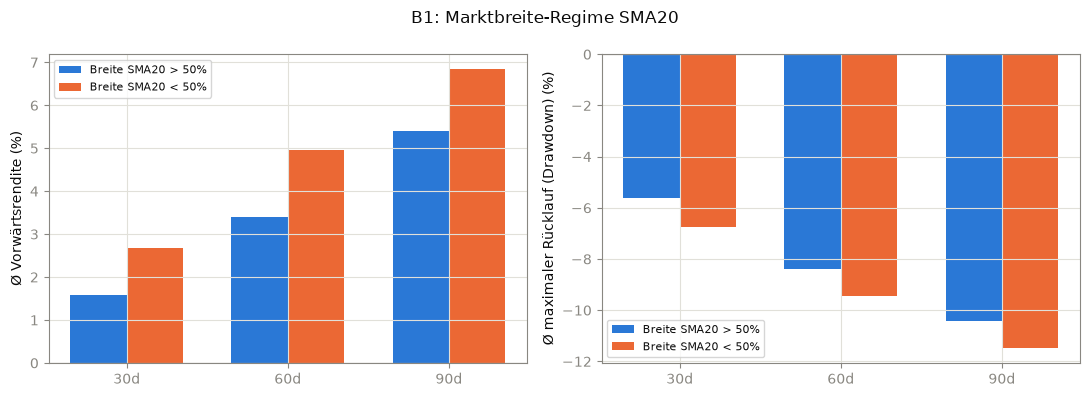

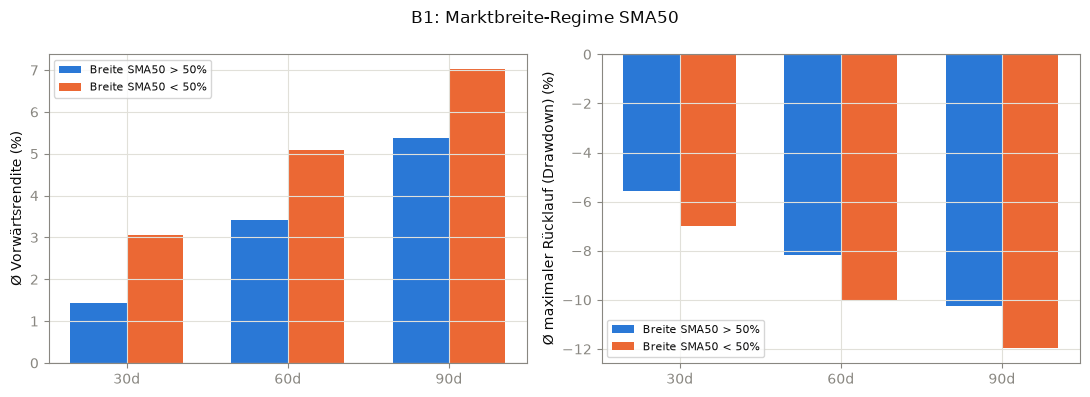

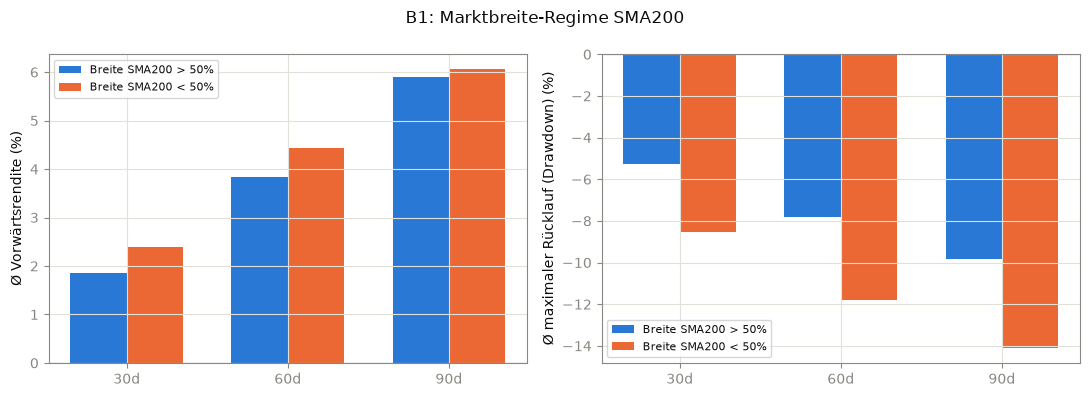

In [13]:
# Diagramm je Fenster
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b1[tabelle_b1["sma_fenster"] == w], f"B1: Marktbreite-Regime SMA{w}")


**Ergebnis:** Das Risikosignal ist über alle drei Fenster durchgehend
signifikant (9 von 9 Kombinationen) - notiert die Mehrheit der Mitglieder
über ihrem SMA, ist der nachfolgende maximale Rücklauf des Gesamtindex in
jedem Fenster und Horizont kleiner als bei Breite < 50 % (z. B. SMA200,
90 Tage: -9,8 % gegenüber -14,1 %). Das Renditesignal ist dagegen
uneinheitlicher: Bei SMA20/50 fällt die mittlere Vorwärtsrendite bei
Breite > 50 % durchgängig **niedriger** aus als bei Breite < 50 %
(Mean-Reversion, signifikant in 6 von 6 Kombinationen); bei SMA200 nähern
sich beide Gruppen an, und der Unterschied ist in keinem der drei
Horizonte signifikant (p zwischen 0,07 und 0,74). Über alle Fenster hinweg
zeigt sich die Marktbreite damit als deutlich robusteres Risikosignal denn
als Renditesignal.


### 4.2 B2 - Richtung der Marktbreite (steigend vs. fallend)

**Hypothese:** Unabhängig vom Niveau der Marktbreite könnte bereits ihre
Richtung (nimmt die Beteiligung gerade zu oder ab?) Information über die
Folgeperiode liefern.


In [14]:
def breite_richtung(fenster: int) -> tuple[pd.Series, pd.Series]:
    breite_diff = df[f"breite_sma{fenster}"].diff()
    steigend = breite_diff > 0
    fallend = breite_diff <= 0
    return steigend, fallend


ergebnisse_b2 = []
for w in BREADTH_WINDOWS:
    steigend, fallend = breite_richtung(w)
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[steigend, f"{ziel}_{h}d"], df.loc[fallend, f"{ziel}_{h}d"],
                label_a=f"Breite SMA{w} steigend", label_b=f"Breite SMA{w} fallend",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_b2.append(res)

tabelle_b2 = ergebnisse_zu_tabelle(ergebnisse_b2)
alle_ergebnisse["B2_Breite_Richtung"] = tabelle_b2
tabelle_b2[spalten_anzeige]


,sma_fenster,horizont_tage,zielgroesse,label_a,mean_a,label_b,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,Breite SMA20 steigend,0.0187,Breite SMA20 fallend,0.0208,0.2938,0.2501,False
1,20,30,fwd_mdd,Breite SMA20 steigend,-0.0602,Breite SMA20 fallend,-0.0605,0.8440,0.3529,False
2,20,60,fwd_return,Breite SMA20 steigend,0.0390,Breite SMA20 fallend,0.0405,0.5876,0.7828,False
3,20,60,fwd_mdd,Breite SMA20 steigend,-0.0876,Breite SMA20 fallend,-0.0879,0.8696,0.7299,False
4,20,90,fwd_return,Breite SMA20 steigend,0.0585,Breite SMA20 fallend,0.0601,0.6115,0.7538,False
5,20,90,fwd_mdd,Breite SMA20 steigend,-0.1077,Breite SMA20 fallend,-0.1087,0.6069,0.4848,False
6,50,30,fwd_return,Breite SMA50 steigend,0.0186,Breite SMA50 fallend,0.0209,0.2349,0.3294,False
7,50,30,fwd_mdd,Breite SMA50 steigend,-0.0596,Breite SMA50 fallend,-0.0611,0.2458,0.0236,False
8,50,60,fwd_return,Breite SMA50 steigend,0.0385,Breite SMA50 fallend,0.0410,0.3491,0.6379,False
9,50,60,fwd_mdd,Breite SMA50 steigend,-0.0873,Breite SMA50 fallend,-0.0882,0.6378,0.2142,False


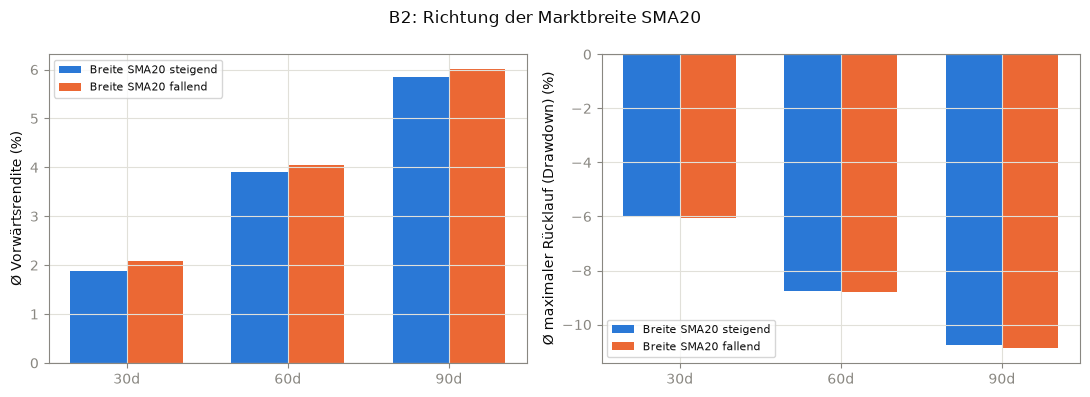

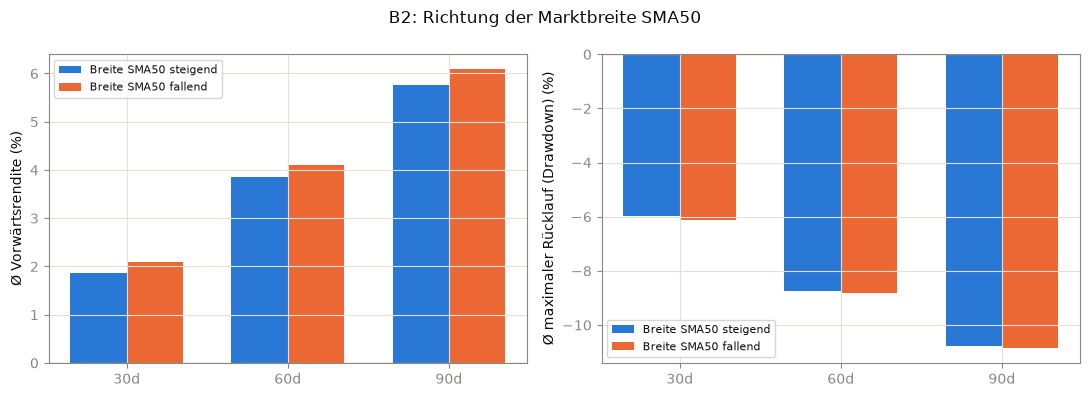

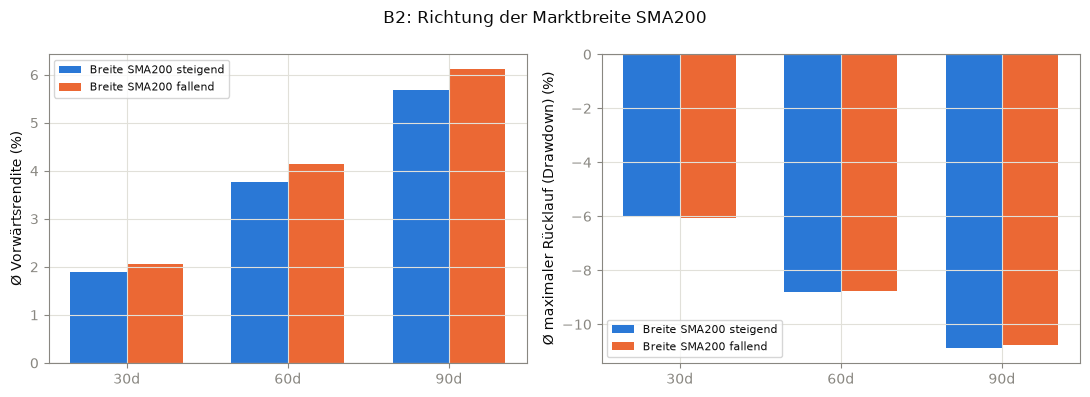

In [15]:
for w in BREADTH_WINDOWS:
    plotte_gruppenvergleich(tabelle_b2[tabelle_b2["sma_fenster"] == w], f"B2: Richtung der Marktbreite SMA{w}")


**Ergebnis:** Anders als das *Niveau* der Marktbreite (B1) liefert ihre
*Richtung* für den NASDAQ 100 überhaupt keine eigenständige Information:
Von 18 geprüften Kombinationen ist keine einzige signifikant - weder beim
Risiko noch bei der Rendite. Insbesondere das bei B1 durchgehend robuste
Risikosignal verschwindet bei B2 vollständig. Ein belastbares Signal lässt
sich aus der Richtung der Marktbreite damit nicht ableiten - vermutlich,
weil die tägliche Richtungsänderung einer bereits stark geglätteten
Prozentkennzahl in hohem Maß Rauschen statt Trend abbildet.


### 4.3 B3 - Marktbreite in Quartilen

**Hypothese:** Die Wirkung der Marktbreite ist nicht binär, sondern
graduell abgestuft: Je höher die Breite (Q4 = 75-100 %), desto günstiger
das Rendite-/Risikoprofil der Folgeperiode; je niedriger (Q1 = 0-25 %), desto
ungünstiger. Getestet wird mit einem Kruskal-Wallis-Omnibustest über alle
vier Quartile sowie einem paarweisen Extremvergleich Q1 vs. Q4.


In [16]:
def breite_quartil(fenster: int) -> pd.Series:
    breite = df[f"breite_sma{fenster}"]
    return pd.cut(breite, bins=QUARTIL_GRENZEN, labels=QUARTIL_LABELS, include_lowest=True)


ergebnisse_b3 = []
for w in BREADTH_WINDOWS:
    quartil = breite_quartil(w)
    df[f"Quartil_SMA{w}"] = quartil
    print(f"SMA{w} - Verteilung der Handelstage auf die Quartile:")
    print(quartil.value_counts().reindex(QUARTIL_LABELS))
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            gruppen = {label: df.loc[quartil == label, f"{ziel}_{h}d"] for label in QUARTIL_LABELS}
            res = vergleiche_quartile(gruppen)
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_b3.append(res)

tabelle_b3 = ergebnisse_zu_tabelle(ergebnisse_b3)
alle_ergebnisse["B3_Breite_Quartile"] = tabelle_b3
cols_b3 = ["sma_fenster", "horizont_tage", "zielgroesse"] + [f"mean_{l}" for l in QUARTIL_LABELS] + \
          ["kw_pvalue", "kw_signifikant_5pct", "q1_vs_q4_signifikant_5pct"]
tabelle_b3[cols_b3]


SMA20 - Verteilung der Handelstage auf die Quartile:
breite_sma20
Q1 (0-25%)       686
Q2 (25-50%)     1141
Q3 (50-75%)     1966
Q4 (75-100%)    1120
Name: count, dtype: int64
SMA50 - Verteilung der Handelstage auf die Quartile:
breite_sma50
Q1 (0-25%)       501
Q2 (25-50%)     1145
Q3 (50-75%)     2116
Q4 (75-100%)    1151
Name: count, dtype: int64
SMA200 - Verteilung der Handelstage auf die Quartile:
breite_sma200
Q1 (0-25%)       322
Q2 (25-50%)      827
Q3 (50-75%)     2261
Q4 (75-100%)    1503
Name: count, dtype: int64


,sma_fenster,horizont_tage,zielgroesse,mean_Q1 (0-25%),mean_Q2 (25-50%),mean_Q3 (50-75%),mean_Q4 (75-100%),kw_pvalue,kw_signifikant_5pct,q1_vs_q4_signifikant_5pct
0,20,30,fwd_return,0.0358,0.0212,0.0157,0.0158,0.0000,True,True
1,20,30,fwd_mdd,-0.0729,-0.0644,-0.0557,-0.0568,0.0000,True,True
2,20,60,fwd_return,0.0580,0.0445,0.0327,0.0363,0.0000,True,True
3,20,60,fwd_mdd,-0.1019,-0.0900,-0.0844,-0.0827,0.0000,True,True
4,20,90,fwd_return,0.0805,0.0611,0.0530,0.0556,0.0000,True,True
5,20,90,fwd_mdd,-0.1217,-0.1107,-0.1053,-0.1026,0.0011,True,True
6,50,30,fwd_return,0.0367,0.0280,0.0131,0.0166,0.0000,True,True
7,50,30,fwd_mdd,-0.0847,-0.0637,-0.0565,-0.0537,0.0000,True,True
8,50,60,fwd_return,0.0510,0.0508,0.0340,0.0345,0.0000,True,True
9,50,60,fwd_mdd,-0.1170,-0.0925,-0.0829,-0.0792,0.0000,True,True


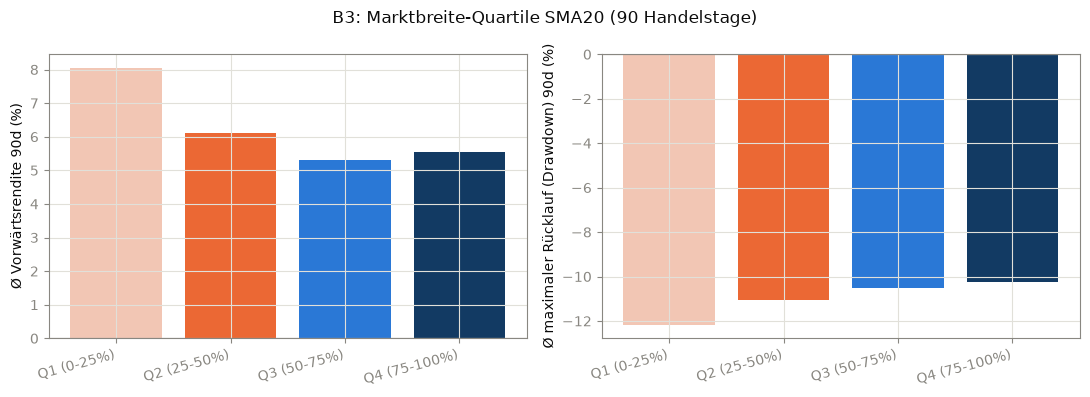

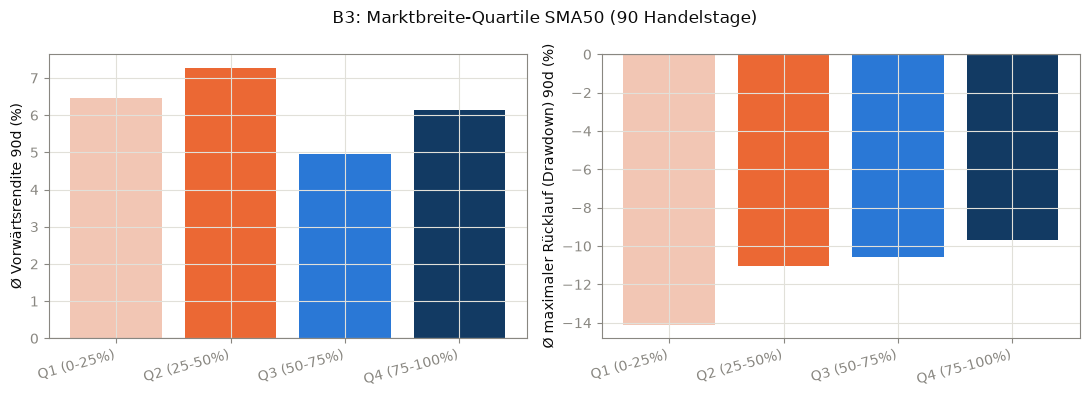

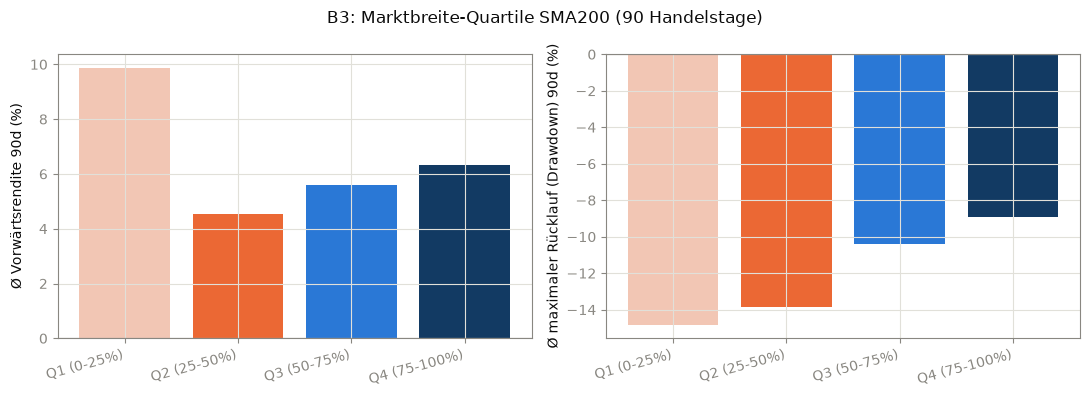

In [17]:
for w in BREADTH_WINDOWS:
    teil_b3 = tabelle_b3[tabelle_b3["sma_fenster"] == w]
    plotte_quartile(teil_b3, 90, f"B3: Marktbreite-Quartile SMA{w} (90 Handelstage)")


**Ergebnis:** Alle 18 Kruskal-Wallis-Omnibustests sind signifikant - die
Marktbreite differenziert die Folgeperiode in jedem Fenster und Horizont
über die vier Quartile hinweg. Das Muster ist auch hier nicht durchgehend
linear: Beim Risiko zeigt sich, besonders deutlich bei SMA200, ein sauberer
monotoner Gradient von Q1 (schwächste Breite, im Mittel größter
90-Tage-Drawdown von -14,8 %) bis Q4 (stärkste Breite, -8,9 %). Bei der
Rendite dominiert dagegen vor allem Q1: Die extrem schwache Breite in Q1
geht mit der **höchsten** mittleren Vorwärtsrendite aller vier Quartile
einher (SMA200/90 Tage: 9,9 % gegenüber 4,6-6,3 % in Q2-Q4) - ein noch
ausgeprägterer Extremquartil-Effekt, bei dem hohe erwartete Rendite und
hohes Risiko gemeinsam auftreten. Der paarweise Extremvergleich Q1 vs. Q4
bestätigt dieses Bild in 17 von 18 Kombinationen; einzige Ausnahme ist die
Rendite bei SMA50/90 Tage, wo sich Q1 und Q4 trotz signifikantem
Omnibustest nicht mehr paarweise signifikant unterscheiden.


### 4.4 B4 - Frühindikator Krise

**Hypothese:** Ausgangslage ist eine breit getragene Rally (SMA200-Breite
> 75 %, bei intaktem SMA20-Breitewert von mindestens 50 %). Fällt die
schnelle SMA20-Breite anschließend unter 50 %, während die träge
SMA200-Breite selbst noch nicht unter 50 % gefallen ist, deutet dies auf eine
beginnende, aber von der breiten Marktlage noch nicht bestätigte Abkühlung
hin - ein möglicher Frühindikator für eine bevorstehende Krise.


In [18]:
def fruehindikator_krise(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    '''Signalisiert den Tag, an dem die SMA20-Breite erstmals unter 50 %
    fällt, nachdem die SMA200-Breite zuvor (bei damals noch >= 50 % liegender
    SMA20-Breite) das obere Quartil (> 75 %) erreicht hatte und selbst noch
    nicht unter 50 % gefallen ist.'''
    signal = pd.Series(False, index=breite_sma20.index)
    war_oben = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 <= 50:
            war_oben = False
            continue
        if b200 > 75 and b20 >= 50:
            war_oben = True
        if war_oben and b20 < 50:
            signal[datum] = True
            war_oben = False
    return signal


signal_b4 = fruehindikator_krise(df["breite_sma20"], df["breite_sma200"])
n_b4 = int(signal_b4.sum())
print(f"B4-Ereignisse identifiziert: {n_b4}")
if n_b4 > 0:
    print(df.index[signal_b4].date)


B4-Ereignisse identifiziert: 116
[datetime.date(2007, 1, 22) datetime.date(2007, 1, 25)
 datetime.date(2007, 2, 27) datetime.date(2007, 5, 14)
 datetime.date(2007, 5, 17) datetime.date(2007, 5, 24)
 datetime.date(2007, 6, 6) datetime.date(2007, 6, 22)
 datetime.date(2007, 7, 26) datetime.date(2007, 10, 19)
 datetime.date(2009, 6, 16) datetime.date(2009, 6, 22)
 datetime.date(2009, 7, 2) datetime.date(2009, 8, 17)
 datetime.date(2009, 9, 1) datetime.date(2009, 10, 1)
 datetime.date(2009, 10, 26) datetime.date(2009, 11, 30)
 datetime.date(2009, 12, 8) datetime.date(2010, 1, 15)
 datetime.date(2010, 1, 20) datetime.date(2010, 4, 30)
 datetime.date(2010, 5, 4) datetime.date(2010, 11, 16)
 datetime.date(2010, 11, 23) datetime.date(2010, 11, 29)
 datetime.date(2011, 1, 21) datetime.date(2011, 1, 28)
 datetime.date(2011, 2, 23) datetime.date(2011, 3, 1)
 datetime.date(2011, 3, 7) datetime.date(2011, 4, 18)
 datetime.date(2011, 5, 16) datetime.date(2011, 5, 20)
 datetime.date(2011, 6, 1) datet

In [19]:
ergebnisse_b4 = []
if n_b4 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b4, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B4-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgroesse": ziel, "n_events": n_b4})
                ergebnisse_b4.append(res)
    tabelle_b4 = ergebnisse_zu_tabelle(ergebnisse_b4)
else:
    # Zu wenige Ereignisse für einen belastbaren Test - Einzelereignisse
    # werden stattdessen deskriptiv mit ihrer tatsächlichen Folgeentwicklung
    # aufgelistet.
    einzelereignisse = df.loc[signal_b4, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b4 = einzelereignisse.reset_index()
    print(f"Nur {n_b4} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B4_Fruehindikator_Krise"] = tabelle_b4
tabelle_b4


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgroesse,n_events
0,B4-Signal,116,0.0253,0.0252,0.0506,Basisrate (alle Tage),4883,0.0198,0.0262,0.0668,0.2499,0.5104,False,30,fwd_return,116
1,B4-Signal,116,-0.0549,-0.0442,0.0401,Basisrate (alle Tage),4883,-0.0604,-0.0460,0.0465,0.1462,0.4028,False,30,fwd_mdd,116
2,B4-Signal,116,0.0492,0.0438,0.0602,Basisrate (alle Tage),4853,0.0398,0.0478,0.0932,0.1034,0.5425,False,60,fwd_return,116
3,B4-Signal,116,-0.0744,-0.0694,0.0455,Basisrate (alle Tage),4853,-0.0878,-0.0724,0.0629,0.0024,0.0754,False,60,fwd_mdd,116
4,B4-Signal,116,0.0763,0.0803,0.0717,Basisrate (alle Tage),4823,0.0593,0.0702,0.1130,0.0147,0.1324,False,90,fwd_return,116
5,B4-Signal,116,-0.0891,-0.0799,0.0487,Basisrate (alle Tage),4823,-0.1082,-0.0857,0.0729,0.0001,0.0178,True,90,fwd_mdd,116


**Ergebnis:** Mit 116 identifizierten Ereignissen seit 2007 ist das Muster
grundsätzlich testbar - eindeutig gegen die Hypothese spricht das Ergebnis
jedoch nur teilweise. Der maximale Vorwärtsrücklauf ist nach dem Signal im
90-Tage-Horizont signifikant **kleiner** (nicht größer) als die Basisrate
(-8,9 % gegenüber -10,8 %); bei 30 und 60 Handelstagen weist der
Unterschied in dieselbe Richtung (-5,5 % gegenüber -6,0 % bzw. -7,4 %
gegenüber -8,8 %), ist aber nicht in beiden Tests gleichzeitig
signifikant. Die Vorwärtsrendite unterscheidet sich in keinem Horizont
signifikant von der Basisrate. Auch für den NASDAQ 100 deutet das Muster
"breit getragene Rally, dann bricht die schnelle SMA20-Breite unter 50 %
ein" damit eher auf eine gesunde Verschnaufpause als auf eine bevorstehende
Krise hin - allerdings mit schwächerer statistischer Absicherung, als das
reine Vorzeichen vermuten lässt. Mit 116 Ereignissen in knapp 20 Jahren (im
Schnitt etwa alle zwei Monate) ist das Muster zudem ohnehin deutlich
häufiger, als der Name "Frühindikator Krise" vermuten lässt.


### 4.5 B5 - Frühindikator Erholung

**Hypothese:** Spiegelbild zu B4. Ausgangslage ist eine breit unterstützte
Schwächephase (SMA200-Breite < 25 %, bei damals noch schwacher
SMA20-Breite <= 50 %). Steigt die schnelle SMA20-Breite anschließend über
50 %, während die SMA200-Breite selbst noch nicht über 50 % gestiegen ist,
deutet dies auf eine beginnende, breitenseitig noch nicht bestätigte
Erholung hin.


In [20]:
def fruehindikator_erholung(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    signal = pd.Series(False, index=breite_sma20.index)
    war_unten = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 >= 50:
            war_unten = False
            continue
        if b200 < 25 and b20 <= 50:
            war_unten = True
        if war_unten and b20 > 50:
            signal[datum] = True
            war_unten = False
    return signal


signal_b5 = fruehindikator_erholung(df["breite_sma20"], df["breite_sma200"])
n_b5 = int(signal_b5.sum())
print(f"B5-Ereignisse identifiziert: {n_b5}")
if n_b5 > 0:
    print(df.index[signal_b5].date)


B5-Ereignisse identifiziert: 30
[datetime.date(2008, 2, 11) datetime.date(2008, 3, 24)
 datetime.date(2008, 10, 31) datetime.date(2008, 12, 5)
 datetime.date(2008, 12, 30) datetime.date(2009, 1, 28)
 datetime.date(2009, 2, 3) datetime.date(2009, 3, 12)
 datetime.date(2011, 8, 29) datetime.date(2011, 10, 6)
 datetime.date(2011, 11, 30) datetime.date(2015, 9, 11)
 datetime.date(2015, 10, 5) datetime.date(2016, 2, 1)
 datetime.date(2016, 2, 17) datetime.date(2019, 1, 7)
 datetime.date(2020, 3, 30) datetime.date(2020, 4, 6)
 datetime.date(2022, 2, 9) datetime.date(2022, 3, 16)
 datetime.date(2022, 5, 26) datetime.date(2022, 6, 24)
 datetime.date(2022, 7, 5) datetime.date(2022, 7, 15)
 datetime.date(2022, 9, 12) datetime.date(2022, 10, 4)
 datetime.date(2022, 10, 18) datetime.date(2022, 10, 21)
 datetime.date(2022, 11, 4) datetime.date(2025, 4, 24)]


In [21]:
ergebnisse_b5 = []
if n_b5 >= 10:
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[signal_b5, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                label_a="B5-Signal", label_b="Basisrate (alle Tage)",
            )
            if res:
                res.update({"horizont_tage": h, "zielgroesse": ziel, "n_events": n_b5})
                ergebnisse_b5.append(res)
    tabelle_b5 = ergebnisse_zu_tabelle(ergebnisse_b5)
else:
    einzelereignisse = df.loc[signal_b5, [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]]
    tabelle_b5 = einzelereignisse.reset_index()
    print(f"Nur {n_b5} Ereignisse - deskriptive Einzelbetrachtung statt Signifikanztest:")

alle_ergebnisse["B5_Fruehindikator_Erholung"] = tabelle_b5
tabelle_b5


,label_a,n_a,mean_a,median_a,std_a,label_b,n_b,mean_b,median_b,std_b,t_pvalue,u_pvalue,signifikant_5pct,horizont_tage,zielgroesse,n_events
0,B5-Signal,30,0.0411,0.0340,0.0727,Basisrate (alle Tage),4883,0.0198,0.0262,0.0668,0.1206,0.1343,False,30,fwd_return,30
1,B5-Signal,30,-0.0880,-0.0793,0.0550,Basisrate (alle Tage),4883,-0.0604,-0.0460,0.0465,0.0103,0.0007,True,30,fwd_mdd,30
2,B5-Signal,30,0.0519,0.0443,0.1204,Basisrate (alle Tage),4853,0.0398,0.0478,0.0932,0.5858,0.7855,False,60,fwd_return,30
3,B5-Signal,30,-0.1160,-0.1132,0.0621,Basisrate (alle Tage),4853,-0.0878,-0.0724,0.0629,0.0191,0.0045,True,60,fwd_mdd,30
4,B5-Signal,30,0.0776,0.0798,0.1570,Basisrate (alle Tage),4823,0.0593,0.0702,0.1130,0.5305,0.6369,False,90,fwd_return,30
5,B5-Signal,30,-0.1383,-0.1183,0.0702,Basisrate (alle Tage),4823,-0.1082,-0.0857,0.0729,0.0264,0.0072,True,90,fwd_mdd,30


**Ergebnis:** 30 Ereignisse seit 2007, historisch plausibel rund um reale
Bodenbildungsphasen konzentriert (2008/2009, 2011, 2015/2016, 2019/2020,
2022). Die Vorwärtsrendite liegt im Mittel durchgehend höher als die
Basisrate (30 Tage: 4,1 % gegenüber 2,0 %; 90 Tage: 7,8 % gegenüber
5,9 %), jedoch in keinem Horizont signifikant (kleine Stichprobe). Der
maximale Vorwärtsrücklauf ist dagegen in allen drei Horizonten signifikant
**größer** als die Basisrate (30 Tage: -8,8 % gegenüber -6,0 %; 90 Tage:
-13,8 % gegenüber -10,8 %) - also das Gegenteil dessen, was eine "ruhige
Erholung" nahelegen würde. Das Signal markiert damit plausibel den Beginn
einer Stabilisierung (leicht höhere Rendite), tritt aber innerhalb noch
volatiler Bodenbildungsphasen auf, in denen das Schwankungsrisiko zunächst
erhöht bleibt - eher ein früher Hinweis auf eine unruhige Bodenbildung als
ein Signal für eine risikoarme Erholung.


### 4.6 Gemeinsames Vorgehen für B6-B9

Die folgenden vier Hypothesen basieren alle auf punktuellen Ereignissen
(Schwellenkreuzungen). Sie werden mit derselben Funktion ausgewertet: Bei
mindestens 10 Ereignissen wird das Ereignis gegen die Basisrate (alle
Handelstage) getestet, bei weniger Ereignissen erfolgt eine deskriptive
Auflistung der Einzelereignisse.


In [22]:
def ereignis_hypothese(event: pd.Series, label: str, extra: dict) -> tuple[list[dict], pd.DataFrame | None]:
    '''Testet ein Ereignis (event=True an den Signaltagen) gegen die
    Basisrate aller Handelstage. Liefert (Ergebnisliste, None) bei
    ausreichender Stichprobe, sonst (leere Liste, Tabelle der
    Einzelereignisse) zur deskriptiven Auflistung.'''
    n = int(event.sum())
    if n >= 10:
        ergebnisse = []
        for h in HORIZONS:
            for ziel in ["fwd_return", "fwd_mdd"]:
                res = vergleiche_gruppen(
                    df.loc[event, f"{ziel}_{h}d"], df[f"{ziel}_{h}d"],
                    label_a=label, label_b="Basisrate (alle Tage)",
                )
                if res:
                    res.update({**extra, "horizont_tage": h, "zielgroesse": ziel, "n_events": n})
                    ergebnisse.append(res)
        return ergebnisse, None
    else:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[event, spalten].reset_index()
        for k, v in extra.items():
            einzel[k] = v
        return [], einzel


print("Gemeinsame Ereignis-Testfunktion definiert.")


Gemeinsame Ereignis-Testfunktion definiert.


### 4.7 B6 - Wochentrend positiv, Marktbreite bricht ein

**Hypothese:** Steigt der Index auf Wochenbasis (Kurs > SMA50_w, ca. 1 Jahr),
die Marktbreite je SMA-Fenster jedoch gleichzeitig (a) aus dem oberen
Quartil heraus oder (b) unter 50 % - deutet dies auf eine zunehmend schmaler
getragene Rally hin, obwohl der Index selbst noch keinen Trendbruch zeigt.
Jedes Fenster (SMA20/50/200) wird einzeln betrachtet.


In [23]:
def kreuzt_abwaerts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher >= schwelle) & (reihe < schwelle)


wochentrend_positiv = df["Wochentrend_positiv"] == 1

ergebnisse_b6 = []
deskriptiv_b6 = []
n_events_b6 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(75, "verlässt oberes Quartil (75%)"), (50, "fällt unter 50%")]:
        event = kreuzt_abwaerts(breite, schwelle) & wochentrend_positiv
        label = f"B6 SMA{w} {bezeichnung}"
        n_events_b6[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b6.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b6.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b6.items():
    print(f"  {label:.<55s} {n}")

tabelle_b6 = ergebnisse_zu_tabelle(ergebnisse_b6)
alle_ergebnisse["B6_Wochentrend_positiv_Breiteneinbruch"] = tabelle_b6
tabelle_deskriptiv_b6 = pd.concat(deskriptiv_b6, ignore_index=True) if deskriptiv_b6 else pd.DataFrame()
if not tabelle_b6.empty:
    display(tabelle_b6[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgroesse",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b6.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b6)


Ereignishäufigkeit je Parametrisierung:
  B6 SMA20 verlässt oberes Quartil (75%)................. 193
  B6 SMA20 fällt unter 50%............................... 243
  B6 SMA50 verlässt oberes Quartil (75%)................. 135
  B6 SMA50 fällt unter 50%............................... 160
  B6 SMA200 verlässt oberes Quartil (75%)................ 90
  B6 SMA200 fällt unter 50%.............................. 61


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt oberes Quartil (75%),193,30,fwd_return,0.0206,0.0198,0.8319,0.9836,False
1,20,verlässt oberes Quartil (75%),193,30,fwd_mdd,-0.0522,-0.0604,0.0019,0.1200,False
2,20,verlässt oberes Quartil (75%),193,60,fwd_return,0.0397,0.0398,0.9839,0.6590,False
3,20,verlässt oberes Quartil (75%),193,60,fwd_mdd,-0.0776,-0.0878,0.0066,0.0834,False
4,20,verlässt oberes Quartil (75%),193,90,fwd_return,0.0573,0.0593,0.7498,0.5233,False
5,20,verlässt oberes Quartil (75%),193,90,fwd_mdd,-0.0990,-0.1082,0.0327,0.3346,False
6,20,fällt unter 50%,243,30,fwd_return,0.0165,0.0198,0.3935,0.3720,False
7,20,fällt unter 50%,243,30,fwd_mdd,-0.0584,-0.0604,0.4665,0.9417,False
8,20,fällt unter 50%,243,60,fwd_return,0.0441,0.0398,0.4053,0.7365,False
9,20,fällt unter 50%,243,60,fwd_mdd,-0.0792,-0.0878,0.0098,0.1575,False


**Ergebnis:** Die sechs Parametrisierungen umfassen zwischen 61 und 243
Ereignissen und sind damit alle gut testbar. Die Rendite unterscheidet
sich in 17 von 18 Kombinationen nicht signifikant von der Basisrate;
einzige Ausnahme ist SMA200 "fällt unter 50 %" im 30-Tage-Horizont, wo die
Rendite signifikant **niedriger** ausfällt (-0,7 % gegenüber 2,0 %) - hier
bestätigt sich die Hypothese im erwarteten Sinn. Beim Risiko zeigt sich ein
uneinheitliches Bild: Bei SMA20 und SMA50 ist in keiner der zwölf
Kombinationen ein signifikanter Unterschied zur Basisrate feststellbar. Bei
SMA200 tritt dagegen ein signifikanter, aber **richtungsabhängiger** Effekt
auf: Verlässt die Breite das obere Quartil, fällt der nachfolgende maximale
Rücklauf in allen drei Horizonten signifikant **kleiner** aus als die
Basisrate (90 Tage: -8,3 % gegenüber -10,8 %) - dem Hypothesentext
entgegengesetzt. Fällt die Breite dagegen unter 50 %, ist der Rücklauf in
den ersten beiden Horizonten signifikant **größer** (30 Tage: -8,3 %
gegenüber -6,0 %; 60 Tage: -10,3 % gegenüber -8,8 %) - hier bestätigt sich
die Warnung. Ein sich abschwächender, aber noch positiver Wochentrend
liefert damit für den NASDAQ 100 kein einheitliches Frühwarnsignal: Je nach
SMA-Fenster und Schwelle deutet der Effekt mal auf eine gesunde
Verschnaufpause, mal auf ein real erhöhtes Risiko hin.


### 4.8 B7 - Wochentrend negativ, Marktbreite stabilisiert sich

**Hypothese:** Spiegelbild zu B6. Fällt der Index auf Wochenbasis (Kurs <=
SMA50_w), die Marktbreite je SMA-Fenster jedoch (a) aus dem unteren Quartil
heraus oder (b) über 50 % - deutet dies auf eine zunehmend breiter
getragene Stabilisierung hin, obwohl der Index selbst noch keinen
Trendwechsel zeigt.


In [24]:
def kreuzt_aufwaerts(reihe: pd.Series, schwelle: float) -> pd.Series:
    vorher = reihe.shift(1)
    return (vorher <= schwelle) & (reihe > schwelle)


wochentrend_negativ = df["Wochentrend_positiv"] == 0

ergebnisse_b7 = []
deskriptiv_b7 = []
n_events_b7 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    for schwelle, bezeichnung in [(25, "verlässt unteres Quartil (25%)"), (50, "steigt über 50%")]:
        event = kreuzt_aufwaerts(breite, schwelle) & wochentrend_negativ
        label = f"B7 SMA{w} {bezeichnung}"
        n_events_b7[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(
            event, label, {"sma_fenster": w, "schwelle": schwelle, "bezeichnung": bezeichnung},
        )
        ergebnisse_b7.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b7.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b7.items():
    print(f"  {label:.<55s} {n}")

tabelle_b7 = ergebnisse_zu_tabelle(ergebnisse_b7)
alle_ergebnisse["B7_Wochentrend_negativ_Breitenstabilisierung"] = tabelle_b7
tabelle_deskriptiv_b7 = pd.concat(deskriptiv_b7, ignore_index=True) if deskriptiv_b7 else pd.DataFrame()
if not tabelle_b7.empty:
    display(tabelle_b7[["sma_fenster", "bezeichnung", "n_events", "horizont_tage", "zielgroesse",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b7.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b7)


Ereignishäufigkeit je Parametrisierung:
  B7 SMA20 verlässt unteres Quartil (25%)................ 65
  B7 SMA20 steigt über 50%............................... 51
  B7 SMA50 verlässt unteres Quartil (25%)................ 44
  B7 SMA50 steigt über 50%............................... 35
  B7 SMA200 verlässt unteres Quartil (25%)............... 36
  B7 SMA200 steigt über 50%.............................. 13


,sma_fenster,bezeichnung,n_events,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,verlässt unteres Quartil (25%),65,30,fwd_return,0.0238,0.0198,0.7600,0.1926,False
1,20,verlässt unteres Quartil (25%),65,30,fwd_mdd,-0.0913,-0.0604,0.0008,0.0001,True
2,20,verlässt unteres Quartil (25%),65,60,fwd_return,0.0508,0.0398,0.5561,0.0573,False
3,20,verlässt unteres Quartil (25%),65,60,fwd_mdd,-0.1263,-0.0878,0.0015,0.0005,True
4,20,verlässt unteres Quartil (25%),65,90,fwd_return,0.0620,0.0593,0.9117,0.1656,False
5,20,verlässt unteres Quartil (25%),65,90,fwd_mdd,-0.1484,-0.1082,0.0041,0.0048,True
6,20,steigt über 50%,51,30,fwd_return,0.0277,0.0198,0.5215,0.2213,False
7,20,steigt über 50%,51,30,fwd_mdd,-0.0911,-0.0604,0.0010,0.0000,True
8,20,steigt über 50%,51,60,fwd_return,0.0242,0.0398,0.4856,0.8475,False
9,20,steigt über 50%,51,60,fwd_mdd,-0.1371,-0.0878,0.0009,0.0000,True


**Ergebnis:** Ereignishäufigkeiten liegen zwischen 13 und 65 - bis auf die
kleinste Parametrisierung (SMA200 "steigt über 50 %", n=13) durchgehend gut
testbar. Die Rendite unterscheidet sich in keiner der 18 Kombinationen
signifikant von der Basisrate. Beim Risiko zeigt sich dagegen ein
durchgehend signifikanter Unterschied bei SMA20 (6 von 6) und SMA50 (6 von
6) sowie bei SMA200 "verlässt unteres Quartil" (3 von 3), insgesamt also 15
von 18 Kombinationen - und zwar wie schon bei B5 in die unerwartete
Richtung: Der maximale Vorwärtsrücklauf fällt **größer** statt kleiner aus
(z. B. SMA20 "verlässt unteres Quartil", 90 Tage: -14,8 % gegenüber
-10,8 % Basisrate). Einzig bei der kleinsten Parametrisierung (SMA200
"steigt über 50 %", n=13) ist keiner der drei Risikovergleiche signifikant.
Ein sich bereits aufhellender, aber noch negativer Wochentrend geht damit
historisch überwiegend nicht mit einer risikoärmeren Erholung einher,
sondern mit anhaltend erhöhter Volatilität - inhaltlich dasselbe Muster wie
bei B5, hier mit deutlich größeren Stichproben statistisch breiter
abgesichert.


### 4.9 B8 - Divergenz: Kurshoch ohne Breitenbestätigung

**Hypothese:** Erreicht der Index ein neues Hoch der letzten w Handelstage,
ist relevant, ob die zugehörige Marktbreite (SMA-Fenster w) diese Bewegung
bestätigt (in den letzten 10 Handelstagen gestiegen) oder nicht (gefallen
oder unverändert). Eine unbestätigte Rally (steigender Kurs, fallende
Beteiligung) gilt in der technischen Analyse als Warnsignal.


In [25]:
DIVERGENZ_LAG = 10

ergebnisse_b8 = []
deskriptiv_b8 = []
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    kurshoch = df["Close"] >= df["Close"].rolling(window=w, min_periods=w).max()
    bestätigt = kurshoch & (breite > breite.shift(DIVERGENZ_LAG))
    nicht_bestaetigt = kurshoch & (breite <= breite.shift(DIVERGENZ_LAG))
    print(f"SMA{w}: {int(kurshoch.sum())} {w}-Tage-Hochs, davon "
          f"{int(bestätigt.sum())} breitenbestätigt und {int(nicht_bestaetigt.sum())} unbestätigt.")

    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[bestätigt, f"{ziel}_{h}d"], df.loc[nicht_bestaetigt, f"{ziel}_{h}d"],
                label_a=f"{w}-Tage-Hoch, Breite bestätigt", label_b=f"{w}-Tage-Hoch, Breite nicht bestätigt",
            )
            if res:
                res.update({"sma_fenster": w, "horizont_tage": h, "zielgroesse": ziel,
                             "n_bestaetigt": int(bestätigt.sum()), "n_nicht_bestaetigt": int(nicht_bestaetigt.sum())})
                ergebnisse_b8.append(res)

    if int(bestätigt.sum()) < 10 or int(nicht_bestaetigt.sum()) < 10:
        spalten = [f"fwd_return_{h}d" for h in HORIZONS] + [f"fwd_mdd_{h}d" for h in HORIZONS]
        einzel = df.loc[kurshoch, spalten + []].reset_index()
        einzel["sma_fenster"] = w
        einzel["breite_bestaetigt"] = bestätigt.loc[kurshoch].values
        deskriptiv_b8.append(einzel)

tabelle_b8 = ergebnisse_zu_tabelle(ergebnisse_b8)
alle_ergebnisse["B8_Divergenz_Kurshoch_Breite"] = tabelle_b8
tabelle_deskriptiv_b8 = pd.concat(deskriptiv_b8, ignore_index=True) if deskriptiv_b8 else pd.DataFrame()
if not tabelle_b8.empty:
    display(tabelle_b8[["sma_fenster", "horizont_tage", "zielgroesse", "n_bestaetigt", "n_nicht_bestaetigt",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])


SMA20: 1090 20-Tage-Hochs, davon 760 breitenbestätigt und 330 unbestätigt.
SMA50: 877 50-Tage-Hochs, davon 646 breitenbestätigt und 231 unbestätigt.
SMA200: 648 200-Tage-Hochs, davon 448 breitenbestätigt und 200 unbestätigt.


,sma_fenster,horizont_tage,zielgroesse,n_bestaetigt,n_nicht_bestaetigt,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,30,fwd_return,760,330,0.0142,0.0171,0.4300,0.3454,False
1,20,30,fwd_mdd,760,330,-0.0536,-0.0520,0.5351,0.7588,False
2,20,60,fwd_return,760,330,0.0303,0.0298,0.9188,0.4370,False
3,20,60,fwd_mdd,760,330,-0.0839,-0.0793,0.2111,0.5131,False
4,20,90,fwd_return,760,330,0.0465,0.0493,0.6399,0.8069,False
5,20,90,fwd_mdd,760,330,-0.1044,-0.1041,0.9573,0.5990,False
6,50,30,fwd_return,646,231,0.0133,0.0158,0.5501,0.3927,False
7,50,30,fwd_mdd,646,231,-0.0517,-0.0524,0.8338,0.9841,False
8,50,60,fwd_return,646,231,0.0287,0.0268,0.7262,0.9742,False
9,50,60,fwd_mdd,646,231,-0.0797,-0.0820,0.5792,0.4055,False


**Ergebnis:** Die große Mehrheit der Hochs ist breitenbestätigt (SMA20:
760 von 1.090; SMA50: 646 von 877; SMA200: 448 von 648). Das Risiko
unterscheidet sich in keiner der neun Kombinationen signifikant zwischen
bestätigten und unbestätigten Hochs. Bei der Rendite ist nur eine einzige
der neun Kombinationen signifikant (SMA200, 90 Tage) - und auch hier fällt
die Vorwärtsrendite nach einem **unbestätigten** Hoch **höher** aus als
nach einem breitenbestätigten (3,3 % gegenüber 5,0 %). Die klassische
Warnung vor einer "nicht bestätigten Rally" bestätigt sich in den Daten
des NASDAQ 100 damit ebenfalls **nicht** - die Richtung deutet, wenn
überhaupt ein Effekt sichtbar wird, auf ein Mean-Reversion-Muster hin,
allerdings mit deutlich schwächerer statistischer Absicherung als bei den
übrigen breitenbasierten Signalen.


### 4.10 B9 - Breadth Thrust und Breadth Collapse

**Hypothese:** Ein schneller Anstieg der Marktbreite von unter 40 % auf über
60 % innerhalb von 10 Handelstagen (Breadth Thrust) gilt in der technischen
Analyse als seltenes, aber kräftiges Kaufsignal (Konzept angelehnt an den
Zweig Breadth Thrust). Der Einbruch von über 60 % auf unter 40 % innerhalb
derselben Frist (Breadth Collapse) wäre das entsprechende Warnsignal.


In [26]:
THRUST_FENSTER = 10
THRUST_UNTEN, THRUST_OBEN = 40, 60

ergebnisse_b9 = []
deskriptiv_b9 = []
n_events_b9 = {}
for w in BREADTH_WINDOWS:
    breite = df[f"breite_sma{w}"]
    minimum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).min()
    maximum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).max()

    thrust = (breite >= THRUST_OBEN) & (minimum_vorher <= THRUST_UNTEN)
    collapse = (breite <= THRUST_UNTEN) & (maximum_vorher >= THRUST_OBEN)

    for event, label in [(thrust, f"B9 SMA{w} Breadth Thrust"), (collapse, f"B9 SMA{w} Breadth Collapse")]:
        n_events_b9[label] = int(event.sum())
        ergebnisse, deskriptiv = ereignis_hypothese(event, label, {"sma_fenster": w, "muster": label})
        ergebnisse_b9.extend(ergebnisse)
        if deskriptiv is not None:
            deskriptiv_b9.append(deskriptiv)

print("Ereignishäufigkeit je Parametrisierung:")
for label, n in n_events_b9.items():
    print(f"  {label:.<40s} {n}")

tabelle_b9 = ergebnisse_zu_tabelle(ergebnisse_b9)
alle_ergebnisse["B9_Breadth_Thrust_Collapse"] = tabelle_b9
tabelle_deskriptiv_b9 = pd.concat(deskriptiv_b9, ignore_index=True) if deskriptiv_b9 else pd.DataFrame()
if not tabelle_b9.empty:
    display(tabelle_b9[["sma_fenster", "muster", "n_events", "horizont_tage", "zielgroesse",
                         "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]])
if not tabelle_deskriptiv_b9.empty:
    print("\nDeskriptiv (weniger als 10 Ereignisse):")
    display(tabelle_deskriptiv_b9)


Ereignishäufigkeit je Parametrisierung:
  B9 SMA20 Breadth Thrust................. 853
  B9 SMA20 Breadth Collapse............... 660
  B9 SMA50 Breadth Thrust................. 280
  B9 SMA50 Breadth Collapse............... 261
  B9 SMA200 Breadth Thrust................ 15
  B9 SMA200 Breadth Collapse.............. 31


,sma_fenster,muster,n_events,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,20,B9 SMA20 Breadth Thrust,853,30,fwd_return,0.0173,0.0198,0.3088,0.5694,False
1,20,B9 SMA20 Breadth Thrust,853,30,fwd_mdd,-0.0578,-0.0604,0.1548,0.0026,False
2,20,B9 SMA20 Breadth Thrust,853,60,fwd_return,0.0406,0.0398,0.7984,0.8984,False
3,20,B9 SMA20 Breadth Thrust,853,60,fwd_mdd,-0.0830,-0.0878,0.0337,0.0103,True
4,20,B9 SMA20 Breadth Thrust,853,90,fwd_return,0.0594,0.0593,0.9789,0.7684,False
5,20,B9 SMA20 Breadth Thrust,853,90,fwd_mdd,-0.1015,-0.1082,0.0086,0.0117,True
6,20,B9 SMA20 Breadth Collapse,660,30,fwd_return,0.0256,0.0198,0.0650,0.0000,False
7,20,B9 SMA20 Breadth Collapse,660,30,fwd_mdd,-0.0682,-0.0604,0.0006,0.0014,True
8,20,B9 SMA20 Breadth Collapse,660,60,fwd_return,0.0512,0.0398,0.0071,0.0000,True
9,20,B9 SMA20 Breadth Collapse,660,60,fwd_mdd,-0.0923,-0.0878,0.1113,0.3344,False


**Ergebnis:** Breadth Thrust (rasche Ausweitung) ist bei keinem der drei
SMA-Fenster in einer der 18 Kombinationen signifikant, auch nicht bei
SMA200 (nur 15 Ereignisse). **Breadth Collapse** (rascher Einbruch) zeigt
dagegen bei allen drei Fenstern zumindest teilweise ein klares Muster:
Sowohl die Vorwärtsrendite als auch das Risiko fallen in mehreren
Kombinationen signifikant **höher** aus als die Basisrate (SMA20/30 Tage:
Drawdown -6,8 % gegenüber -6,0 %; SMA200/60 Tage: Rendite 11,3 % gegenüber
4,0 %, Drawdown -10,4 % gegenüber -8,8 %) - ein rascher Breiteneinbruch
fällt historisch mit kurzfristigen Panikphasen zusammen, auf die im Mittel
eine überdurchschnittliche Erholung folgt, allerdings bei gleichzeitig
erhöhtem Risiko. Bei 90 Handelstagen schwächt sich der Effekt bei allen
drei Fenstern wieder ab und ist trotz teils großer Punktschätzer nicht mehr
durchgehend signifikant. Wie schon bei B5 und B7 ist bei Breadth Collapse
damit nicht nur das Risiko, sondern zugleich die Rendite betroffen - ein
klassisches Risiko-Rendite-Muster statt eines reinen Warnsignals.


### 4.11 Übergreifende Robustheitsübersicht

Fasst über alle getesteten Parametrisierungen je Hypothese den Anteil
signifikanter Kombinationen zusammen - getrennt für Rendite und Risiko.
Ereignishypothesen mit weniger als 10 Fällen (nur deskriptiv ausgewiesen)
tragen keine testbaren Zeilen bei und erscheinen daher ggf. nicht oder nur
mit wenigen Zeilen in dieser Übersicht.


In [27]:
robustheit = []
for name, tabelle in alle_ergebnisse.items():
    if "zielgroesse" not in tabelle.columns:
        continue
    # B3 (Quartile) nutzt den Kruskal-Wallis-Omnibustest statt des paarweisen
    # Welch-t-/Mann-Whitney-Verfahrens der übrigen Hypothesen und hat daher
    # eine andere Signifikanzspalte.
    if "signifikant_5pct" in tabelle.columns:
        sig_spalte = "signifikant_5pct"
    elif "kw_signifikant_5pct" in tabelle.columns:
        sig_spalte = "kw_signifikant_5pct"
    else:
        continue
    for ziel in ["fwd_return", "fwd_mdd"]:
        teil = tabelle[tabelle["zielgroesse"] == ziel]
        if len(teil) == 0:
            continue
        robustheit.append({
            "hypothese": name, "zielgroesse": ziel,
            "getestete_kombinationen": len(teil),
            "anteil_signifikant": teil[sig_spalte].mean(),
        })

tabelle_robustheit = pd.DataFrame(robustheit)
pivot_robustheit = tabelle_robustheit.pivot(index="hypothese", columns="zielgroesse", values="anteil_signifikant")
pivot_robustheit = pivot_robustheit.rename(columns={"fwd_return": "Anteil signifikant (Rendite)",
                                                     "fwd_mdd": "Anteil signifikant (Risiko)"})
pivot_robustheit


zielgroesse,Anteil signifikant (Risiko),Anteil signifikant (Rendite)
hypothese,,
B1_Breite_Regime,1.0000,0.6667
B2_Breite_Richtung,0.0000,0.0000
B3_Breite_Quartile,1.0000,1.0000
B4_Fruehindikator_Krise,0.3333,0.0000
B5_Fruehindikator_Erholung,1.0000,0.0000
B6_Wochentrend_positiv_Breiteneinbruch,0.2778,0.0556
B7_Wochentrend_negativ_Breitenstabilisierung,0.8333,0.0000
B8_Divergenz_Kurshoch_Breite,0.0000,0.1111
B9_Breadth_Thrust_Collapse,0.3889,0.2778


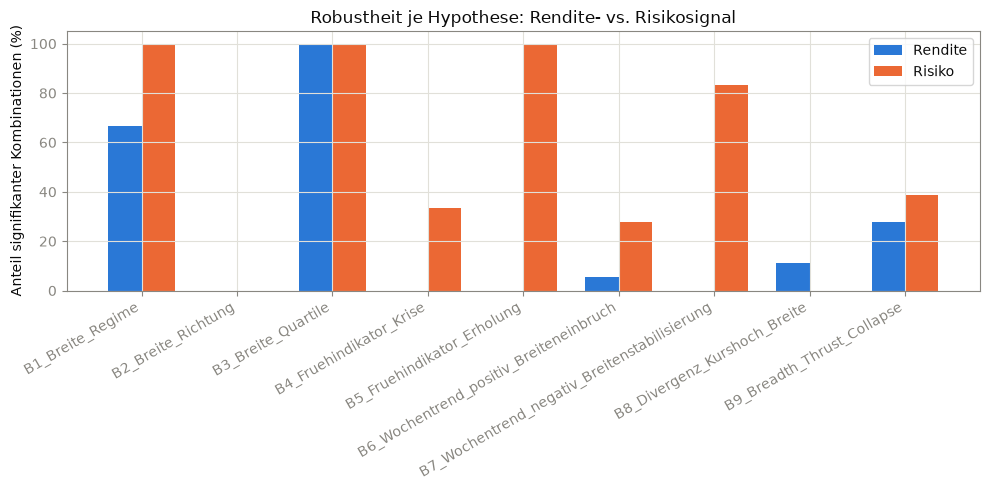

In [28]:
fig, achse = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot_robustheit))
breite = 0.35
achse.bar(x - breite / 2, pivot_robustheit["Anteil signifikant (Rendite)"] * 100, breite, label="Rendite", color=COLOR_A)
achse.bar(x + breite / 2, pivot_robustheit["Anteil signifikant (Risiko)"] * 100, breite, label="Risiko", color=COLOR_B)
achse.set_xticks(x)
achse.set_xticklabels(pivot_robustheit.index, rotation=30, ha="right")
achse.set_ylabel("Anteil signifikanter Kombinationen (%)")
achse.legend()
plt.title("Robustheit je Hypothese: Rendite- vs. Risikosignal")
plt.tight_layout()
plt.show()


**Ergebnis:** Anteil signifikanter Kombinationen (Risiko / Rendite) je
Hypothese: B1 100 %/67 %, B2 0 %/0 %, B3 100 %/100 %, B4 33 %/0 %, B5
100 %/0 %, B6 28 %/6 %, B7 83 %/0 %, B8 0 %/11 %, B9 39 %/28 %. Bei sieben
der neun Hypothesen (B1, B3, B4, B5, B6, B7, B9) ist das Risikosignal
häufiger signifikant als das Renditesignal, bei B2 liegen beide gleichauf
(jeweils 0 %) - die Marktbreite ist damit auch für den NASDAQ 100
insgesamt ein deutlich robusteres Risiko- als Renditesignal. Einzige echte
Ausnahme mit umgekehrtem Muster ist B8 (Divergenz Kurshoch/Breite), das
ausschließlich bei der Rendite ein (schwaches) Signal liefert - dort
allerdings in der dem klassischen Warnsignal entgegengesetzten Richtung
(siehe 4.9).


## 5. Einordnung und Handlungsempfehlungen


Die neun Hypothesen zeigen insgesamt ein weitgehend konsistentes Bild:
Technische Signale auf Basis der Marktbreite sagen für den NASDAQ 100
deutlich mehr über das Risiko als über die Rendite der Folgeperiode aus.
In den *sequenziellen* Ereignishypothesen (B4-B8), die allesamt als
Warnsignal formuliert waren, zeigt sich überwiegend entweder kein Effekt
oder ein dem Hypothesentext **entgegengesetzter** Effekt: B4
(Frühindikator Krise) deutet - wenn auch nur im 90-Tage-Horizont
statistisch abgesichert - auf geringeres statt höheres Risiko hin; B5, B7
und B9 (Collapse) zeigen anhaltend erhöhte statt sinkende Volatilität in
ohnehin schon turbulenten Phasen; B8 zeigt bei unbestätigten Hochs eine
leicht höhere statt niedrigere Rendite. Eine Ausnahme von diesem
einheitlichen Bild bildet B6: Hier hängt die Richtung des Effekts von der
konkreten Parametrisierung ab - bei SMA20/SMA50 zeigt sich gar kein
signifikanter Effekt, bei SMA200 je nach Schwellenwert mal ein dem
Hypothesentext entgegengesetzter, mal ein die Warnung bestätigender
Effekt. Die *zustandsbasierten* Hypothesen B1 und B3 (Marktbreite-Niveau)
bleiben dagegen auch für den NASDAQ 100 die robustesten und am klarsten
interpretierbaren Bausteine; B2 (Richtung der Marktbreite) liefert
demgegenüber überhaupt kein eigenständiges Signal.

**Praxisrelevanz:** Für ein Ampelsystem eignet sich die Marktbreite auch
beim NASDAQ 100 vor allem als Niveau-Kennzahl (B1/B3), nicht als Trigger
für punktuelle Schwellenkreuzungen. Die in mehreren Hypothesen
wiederkehrende Mean-Reversion-Wirkung (schwache Breite bzw. unbestätigte
Hochs -> im Mittel höhere Folgerendite) deutet darauf hin, dass
kurzfristige Breitensignale eher gegenläufig als bestätigend zu
interpretieren sind - bei B6 allerdings mit der Einschränkung, dass sich
je nach SMA-Fenster und Schwelle auch das erwartete Warnmuster bestätigen
kann.


## 6. Ampel-Systematik auf Basis der Marktbreite


### 6.1 Bausteine: Breiten-Trend-Score (B1 + B2) und Drawdown-Stufe

Ein **Breiten-Trend-Score** wird aus B1 (Marktbreite-Regime) und B2
(Richtung der Marktbreite) auf dem langfristigen SMA200-Fenster gebildet
und mit einer **Drawdown-Stufe** (Abstand des Index vom bisherigen Hoch)
kombiniert. Die Kombination aus Trend- und Risikoachse soll zeigen, ob die
Marktbreite als eigenständiger Baustein einer Ampel-Systematik einen
Mehrwert liefert.


In [29]:
def trend_score(zustand_gut: pd.Series, zustand_steigend: pd.Series) -> pd.Series:
    # 0 = beide Bedingungen günstig, 2 = beide ungünstig, 1 = gemischt.
    valide = zustand_gut.notna() & zustand_steigend.notna()
    score = pd.Series(np.nan, index=df.index)
    score[valide & zustand_gut & zustand_steigend] = 0
    score[valide & (zustand_gut != zustand_steigend)] = 1
    score[valide & ~zustand_gut & ~zustand_steigend] = 2
    return score


breite_sma200_ueber_50 = df["breite_sma200"] > 50
breite_sma200_steigend = df["breite_sma200"].diff() > 0
df["Breiten_Trend_Score"] = trend_score(breite_sma200_ueber_50, breite_sma200_steigend)

# Drawdown-Stufe (Abstand vom bisherigen Hoch), direkt aus dem Indexkurs
# berechnet.
df["Allzeithoch"] = df["Close"].cummax()
df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)
bucket_reihenfolge = ["Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)",
                      "Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]

print("Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):")
print(df["Breiten_Trend_Score"].value_counts().sort_index())


Verteilung des Breiten-Trend-Score (0 = günstig, 2 = ungünstig):
Breiten_Trend_Score
0.0000    1586
1.0000    2645
2.0000     682
Name: count, dtype: int64


### 6.2 Empirische Grundlage der Kategoriengrenzen


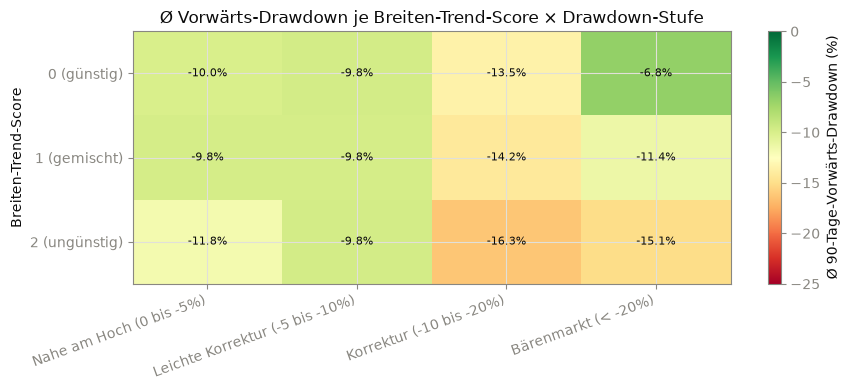

Drawdown_Bucket,Nahe am Hoch (0 bis -5%),Leichte Korrektur (-5 bis -10%),Korrektur (-10 bis -20%),Bärenmarkt (< -20%)
Breiten_Trend_Score,,,,
0.0000,-0.0999,-0.0976,-0.1351,-0.0680
1.0000,-0.0983,-0.0979,-0.1417,-0.1136
2.0000,-0.1176,-0.0976,-0.1627,-0.1509


In [30]:
heatmap_basis = df.groupby(["Breiten_Trend_Score", "Drawdown_Bucket"])["fwd_mdd_90d"].mean().unstack()
heatmap_basis = heatmap_basis[bucket_reihenfolge]

fig, achse = plt.subplots(figsize=(9, 4))
bild = achse.imshow(heatmap_basis.values * 100, cmap="RdYlGn", aspect="auto", vmin=-25, vmax=0)
achse.set_xticks(range(len(bucket_reihenfolge)))
achse.set_xticklabels(bucket_reihenfolge, rotation=20, ha="right")
achse.set_yticks(range(3))
achse.set_yticklabels(["0 (günstig)", "1 (gemischt)", "2 (ungünstig)"])
achse.set_ylabel("Breiten-Trend-Score")
for i in range(heatmap_basis.shape[0]):
    for j in range(heatmap_basis.shape[1]):
        wert = heatmap_basis.values[i, j]
        if not np.isnan(wert):
            achse.text(j, i, f"{wert * 100:.1f}%", ha="center", va="center", fontsize=8)
fig.colorbar(bild, ax=achse, label="Ø 90-Tage-Vorwärts-Drawdown (%)")
plt.title("Ø Vorwärts-Drawdown je Breiten-Trend-Score × Drawdown-Stufe")
plt.tight_layout()
plt.show()
heatmap_basis


### 6.3 Kategorienregel


In [31]:
def ampel_farbe(trend_score: float, drawdown_bucket: str) -> str:
    günstig = trend_score == 0
    ungünstig = trend_score == 2
    tief = drawdown_bucket in ("Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)")
    flach = drawdown_bucket in ("Nahe am Hoch (0 bis -5%)", "Leichte Korrektur (-5 bis -10%)")

    if günstig and flach:
        return "Grün"
    if ungünstig and tief:
        return "Rot"
    return "Gelb"


df["Ampel"] = [
    ampel_farbe(ts, db) if pd.notna(ts) else np.nan
    for ts, db in zip(df["Breiten_Trend_Score"], df["Drawdown_Bucket"])
]

print("Verteilung der Handelstage auf die drei Ampelfarben:")
print(df["Ampel"].value_counts().reindex(["Grün", "Gelb", "Rot"]))


Verteilung der Handelstage auf die drei Ampelfarben:
Ampel
Grün    1392
Gelb    3042
Rot      479
Name: count, dtype: int64


### 6.4 Statistische Validierung der Ampelfarben


In [32]:
ampel_farben = ["Grün", "Gelb", "Rot"]
ampel_paare = [("Grün", "Gelb"), ("Gelb", "Rot"), ("Grün", "Rot")]

ergebnisse_ampel = []
for a, b in ampel_paare:
    maske_a = df["Ampel"] == a
    maske_b = df["Ampel"] == b
    for h in HORIZONS:
        for ziel in ["fwd_return", "fwd_mdd"]:
            res = vergleiche_gruppen(
                df.loc[maske_a, f"{ziel}_{h}d"], df.loc[maske_b, f"{ziel}_{h}d"],
                label_a=a, label_b=b,
            )
            if res:
                res.update({"vergleich": f"{a} vs. {b}", "horizont_tage": h, "zielgroesse": ziel})
                ergebnisse_ampel.append(res)

tabelle_ampel = ergebnisse_zu_tabelle(ergebnisse_ampel)
tabelle_ampel[["vergleich", "horizont_tage", "zielgroesse", "mean_a", "mean_b", "t_pvalue", "u_pvalue", "signifikant_5pct"]]


,vergleich,horizont_tage,zielgroesse,mean_a,mean_b,t_pvalue,u_pvalue,signifikant_5pct
0,Grün vs. Gelb,30,fwd_return,0.0144,0.0219,0.0001,0.0000,True
1,Grün vs. Gelb,30,fwd_mdd,-0.0525,-0.0583,0.0000,0.0000,True
2,Grün vs. Gelb,60,fwd_return,0.0327,0.0423,0.0001,0.0000,True
3,Grün vs. Gelb,60,fwd_mdd,-0.0783,-0.0850,0.0002,0.0006,True
4,Grün vs. Gelb,90,fwd_return,0.0512,0.0622,0.0003,0.0000,True
5,Grün vs. Gelb,90,fwd_mdd,-0.0995,-0.1044,0.0197,0.1159,False
6,Gelb vs. Rot,30,fwd_return,0.0219,0.0223,0.9278,0.7994,False
7,Gelb vs. Rot,30,fwd_mdd,-0.0583,-0.0964,0.0000,0.0000,True
8,Gelb vs. Rot,60,fwd_return,0.0423,0.0446,0.7382,0.1727,False
9,Gelb vs. Rot,60,fwd_mdd,-0.0850,-0.1322,0.0000,0.0000,True


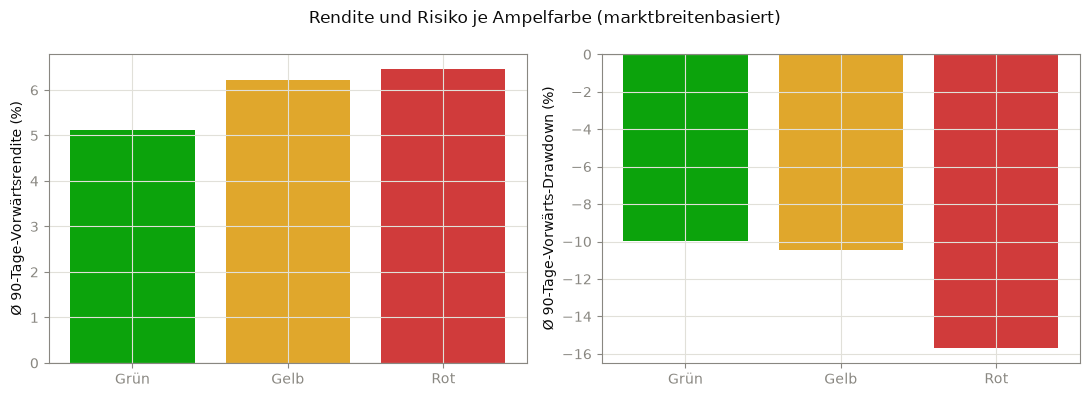

In [33]:
mittelwerte_ampel = df.groupby("Ampel")[["fwd_return_90d", "fwd_mdd_90d"]].mean().reindex(ampel_farben)
ampel_farbcodes = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

fig, achsen = plt.subplots(1, 2, figsize=(11, 4))
for achse, spalte, titel in zip(achsen, ["fwd_return_90d", "fwd_mdd_90d"],
                                 ["Ø 90-Tage-Vorwärtsrendite", "Ø 90-Tage-Vorwärts-Drawdown"]):
    achse.bar(mittelwerte_ampel.index, mittelwerte_ampel[spalte] * 100,
              color=[ampel_farbcodes[f] for f in mittelwerte_ampel.index])
    achse.axhline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_ylabel(f"{titel} (%)")
fig.suptitle("Rendite und Risiko je Ampelfarbe (marktbreitenbasiert)")
fig.tight_layout()
plt.show()


**Ergebnis:** Verteilung der Handelstage: Grün 1.392 (28,3 %), Gelb 3.042
(61,9 %), Rot 479 (9,7 %). Das Risiko trennt Gelb/Rot und Grün/Rot in
allen drei Horizonten signifikant und monoton (mittlerer
90-Tage-Drawdown: Grün -10,0 %, Gelb -10,4 %, Rot -15,7 %); zwischen Grün
und Gelb ist der Unterschied bei 30 und 60 Tagen ebenfalls signifikant,
bei 90 Tagen nicht mehr. Bei der Rendite zeigt sich ein auffälliges,
gegenläufiges Bild: Zwischen Grün und Gelb ist der Unterschied in allen
drei Horizonten signifikant - allerdings mit **höherer**, nicht
niedrigerer Rendite in der ungünstigeren Gelb-Kategorie (90 Tage: Grün
5,1 % gegenüber Gelb 6,2 %); zwischen Gelb und Rot bzw. Grün und Rot ist
dagegen in keinem Horizont ein signifikanter Renditeunterschied
feststellbar (90-Tage-Rendite: Gelb 6,2 %, Rot 6,5 %, praktisch identisch
zur Gelb-Kategorie). Die marktbreitenbasierte Ampel funktioniert damit für
den NASDAQ 100 klar als Risikostufung; als Renditeprognose liefert sie
dagegen kein durchgehend nutzbares Signal und deutet in der
Grün/Gelb-Abstufung sogar auf eine leichte Mean-Reversion hin (etwas
geringere statt höhere Rendite in der günstigsten Kategorie).


### 6.5 Ampel-Hintergrund im Kursverlauf


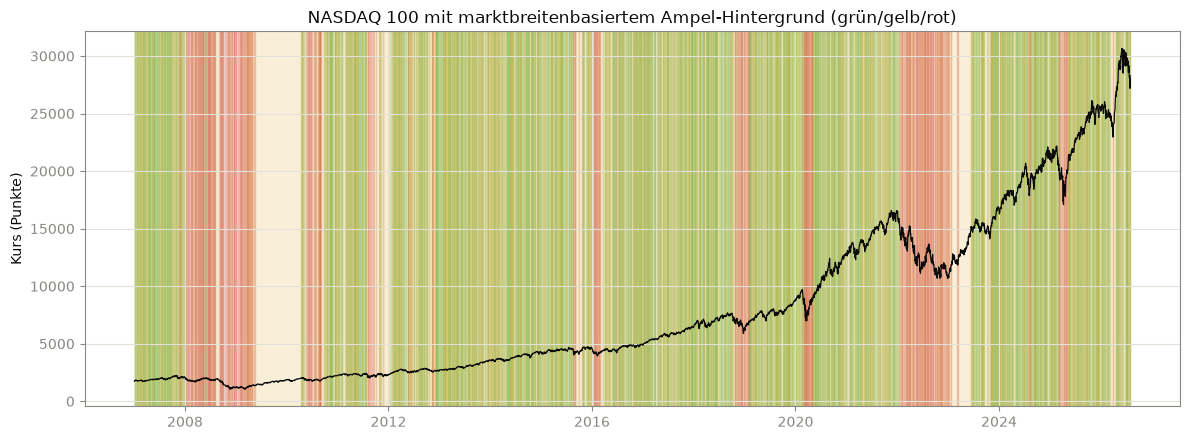

In [34]:
fig, achse = plt.subplots(figsize=(12, 4.5))
for farbe in ampel_farben:
    maske = df["Ampel"] == farbe
    achse.fill_between(df.index, 0, 1, where=maske, color=ampel_farbcodes[farbe], alpha=0.18,
                        transform=achse.get_xaxis_transform())
achse.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
achse.set_ylabel("Kurs (Punkte)")
achse.set_title(f"{INDEX_NAME} mit marktbreitenbasiertem Ampel-Hintergrund (grün/gelb/rot)")
fig.tight_layout()
plt.show()


## 7. Was-wäre-wenn-Analyse: Wirkung des Risikophasen-Ausschlusses

Für jede Hypothese, bei der sich ein **anhaltender** Regimezustand
definieren lässt (im Unterschied zu den punktuellen Ereignishypothesen
B4-B9), wird simuliert, wie sich Gesamtrendite, annualisierte Rendite (CAGR)
und maximaler Drawdown verändert hätten, wenn an Tagen mit dem jeweils
ungünstigeren Regimezustand nicht investiert gewesen wäre.

**Methodische Abgrenzung:** Es wird ausschließlich der zum jeweiligen
Zeitpunkt bereits bekannte Regimezustand verwendet (kein Rückschaufehler).
Transaktionskosten und eine Verzinsung der Cash-Position an ausgeschlossenen
Tagen werden nicht berücksichtigt.

**B4, B5, B6, B7, B8 und B9 werden bewusst ausgeschlossen:** Es handelt sich
um seltene Punktereignisse bzw. Divergenzsignale ohne anhaltenden
Regimezustand - daraus lässt sich keine Phase ableiten, die über einen
längeren Zeitraum "ausgeschlossen" werden könnte. Einbezogen werden B1
(Marktbreite-Regime), B2 (Richtung der Marktbreite), B3 (unteres Quartil als
Risikostufe) sowie die kombinierte Ampel aus Abschnitt 6.


### 7.1 Backtest-Hilfsfunktionen


In [35]:
def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(schlecht: pd.Series, label: str) -> dict:
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)

    strategie_rendite = tagesrendite.where(~schlecht_bereinigt, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 Regime-Definitionen je Hypothese


In [36]:
regime_definitionen: dict[str, pd.Series] = {}

for w in BREADTH_WINDOWS:
    über, _ = breite_regime(w)
    regime_definitionen[f"B1_SMA{w}"] = ~über.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    steigend, _ = breite_richtung(w)
    regime_definitionen[f"B2_SMA{w}"] = ~steigend.reindex(df.index).fillna(False)

for w in BREADTH_WINDOWS:
    regime_definitionen[f"B3_SMA{w}_Q1"] = df[f"Quartil_SMA{w}"] == QUARTIL_LABELS[0]

regime_definitionen["Ampel_Rot"] = df["Ampel"] == "Rot"

print("Regime-Definitionen für die Was-wäre-wenn-Analyse:", list(regime_definitionen.keys()))


Regime-Definitionen für die Was-wäre-wenn-Analyse: ['B1_SMA20', 'B1_SMA50', 'B1_SMA200', 'B2_SMA20', 'B2_SMA50', 'B2_SMA200', 'B3_SMA20_Q1', 'B3_SMA50_Q1', 'B3_SMA200_Q1', 'Ampel_Rot']


### 7.3 Konsolidierte Kennzahlenübersicht


In [37]:
ergebnisse_www = [was_waere_wenn(schlecht, name) for name, schlecht in regime_definitionen.items()]
tabelle_was_waere_wenn = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])
tabelle_was_waere_wenn


,hypothese,anteil_schlecht_tage,gesamtrendite_buy_hold,cagr_buy_hold,max_drawdown_buy_hold,gesamtrendite_strategie,cagr_strategie,max_drawdown_strategie
0,B1_SMA20,0.3719,15.0706,0.1524,-0.5371,"26,072.8727",0.6812,-0.0654
1,B1_SMA50,0.3350,15.0706,0.1524,-0.5371,"1,649.7659",0.4601,-0.0865
2,B1_SMA200,0.2339,15.0706,0.1524,-0.5371,95.3762,0.2629,-0.1278
3,B2_SMA20,0.5292,15.0706,0.1524,-0.5371,"1,909,150,140.1119",1.9797,-0.0537
4,B2_SMA50,0.5329,15.0706,0.1524,-0.5371,"1,146,111,851.6950",1.9030,-0.0537
5,B2_SMA200,0.5821,15.0706,0.1524,-0.5371,"93,177,763.7904",1.5536,-0.0537
6,B3_SMA20_Q1,0.1396,15.0706,0.1524,-0.5371,"7,204.0649",0.5743,-0.1208
7,B3_SMA50_Q1,0.1020,15.0706,0.1524,-0.5371,337.0172,0.3465,-0.1487
8,B3_SMA200_Q1,0.0655,15.0706,0.1524,-0.5371,85.1096,0.2556,-0.2079
9,Ampel_Rot,0.0975,15.0706,0.1524,-0.5371,"17,960.3796",0.6495,-0.1278


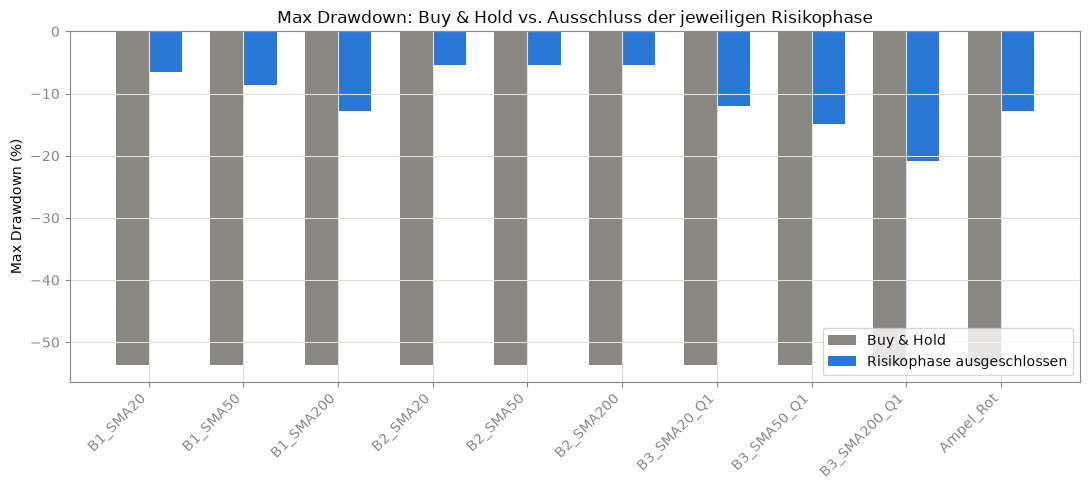

In [38]:
fig, achse = plt.subplots(figsize=(11, 5))
x = np.arange(len(tabelle_was_waere_wenn))
breite = 0.35
achse.bar(x - breite / 2, tabelle_was_waere_wenn["max_drawdown_buy_hold"] * 100, breite,
          label="Buy & Hold", color=COLOR_MUTED)
achse.bar(x + breite / 2, tabelle_was_waere_wenn["max_drawdown_strategie"] * 100, breite,
          label="Risikophase ausgeschlossen", color=COLOR_A)
achse.set_xticks(x)
achse.set_xticklabels(tabelle_was_waere_wenn["hypothese"], rotation=45, ha="right")
achse.set_ylabel("Max Drawdown (%)")
achse.legend()
plt.title("Max Drawdown: Buy & Hold vs. Ausschluss der jeweiligen Risikophase")
plt.tight_layout()
plt.show()


**Ergebnis:** Buy & Hold erzielt seit 2007 eine Gesamtrendite von 1.507 %
(CAGR 15,2 %) bei einem Max Drawdown von -53,7 %. Der Ausschluss der
jeweils "schlechten" Marktbreite-Regime senkt den Max Drawdown in allen
zehn Parametrisierungen deutlich, am stärksten bei B2 (SMA20/50/200
fallend, einheitlich auf -5,4 %) und bei B1/SMA20 (-6,5 %).

**Wichtiger Vorbehalt zu B2:** Die dort ausgewiesenen CAGR-Werte von 155 %
bis 198 % und die extrem hohen Gesamtrenditen sind ein Artefakt der
kostenfreien, reibungslosen Simulation - B2 markiert an 53 bis 58 % aller
Handelstage einen Regimewechsel (die Richtung der Marktbreite kippt sehr
häufig), was in der Praxis täglichen Ein- und Ausstieg ohne
Transaktionskosten oder Slippage bedeuten würde. Das deckt sich mit dem
Befund aus Abschnitt 4.2, wo B2 in keiner der 18 getesteten Kombinationen
ein statistisch signifikantes Signal lieferte - die hier simulierte
Wirkung ist ein rechnerisches Maximum, keine handelbare Strategie.

Realistischer interpretierbar sind die trägeren Regime-Definitionen:
B1/SMA200 (23,4 % ausgeschlossene Tage, CAGR 26,3 %, Max Drawdown
-12,8 %), B3/SMA200_Q1 (6,6 % ausgeschlossene Tage, CAGR 25,6 %, Max
Drawdown -20,8 %) und die kombinierte Ampel (9,7 % ausgeschlossene Tage,
CAGR 65,0 %, Max Drawdown -12,8 %) - letztere mit deutlich höherer CAGR
bei vergleichbarem Drawdown wie B1/SMA200, was für einen Mehrwert der
gezielten Verknüpfung von Trend- und Risikostufe gegenüber einem
einzelnen Signal spricht.


### 7.4 Vertiefte Einzelbetrachtung

Für die kombinierte Ampel (Rot-Phasen) wird zusätzlich der zeitliche
Verlauf dargestellt: oben der Kursverlauf mit rot hinterlegter
Ausschlussphase, darunter die Wertentwicklung von Buy & Hold gegenüber der
Ausschluss-Strategie (logarithmische Skala, Startwert = 1).


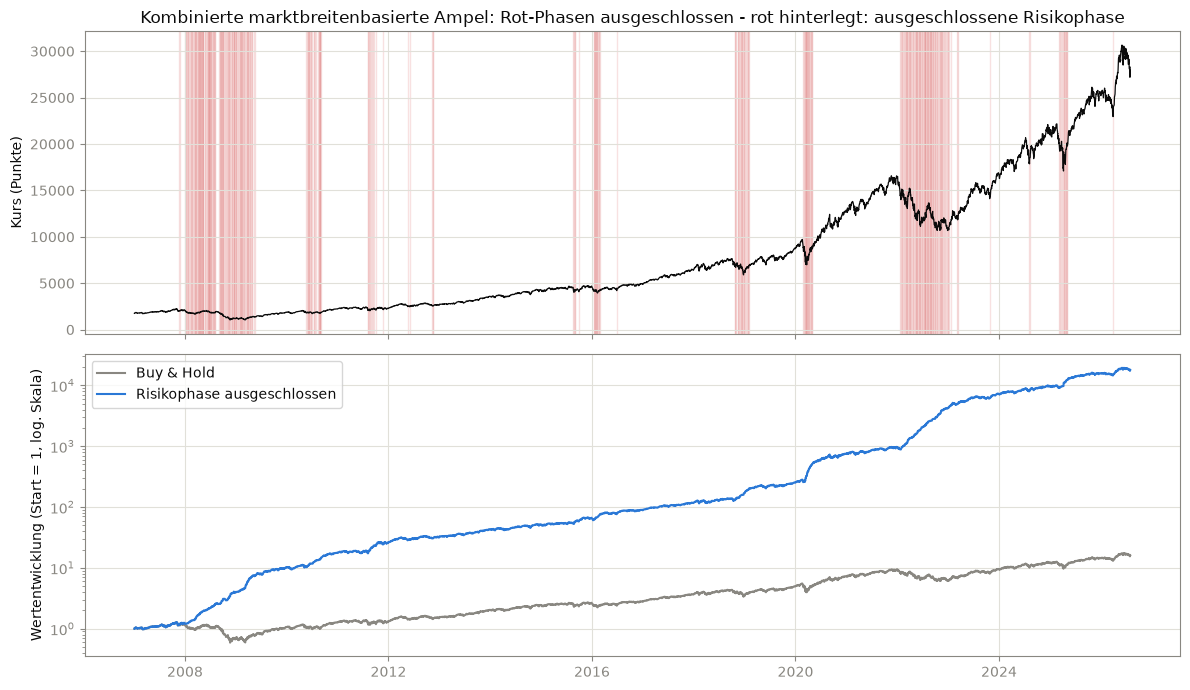

Anteil ausgeschlossener Handelstage: 9.7%
Gesamtrendite  - Buy & Hold: 1507.1% | Ausschluss: 1796038.0%
CAGR           - Buy & Hold: 15.2% | Ausschluss: 65.0%
Max Drawdown   - Buy & Hold: -53.7% | Ausschluss: -12.8%


In [39]:
def plotte_was_waere_wenn(name: str, schlecht: pd.Series, titel: str) -> dict:
    ergebnis = was_waere_wenn(schlecht, name)
    schlecht_reindiziert = schlecht.reindex(df.index).fillna(False)

    fig, (achse_kurs, achse_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    achse_kurs.fill_between(df.index, 0, 1, where=schlecht_reindiziert, color=COLOR_BAD, alpha=0.15,
                             transform=achse_kurs.get_xaxis_transform())
    achse_kurs.plot(df.index, df["Close"], color=COLOR_PRICE, linewidth=0.9)
    achse_kurs.set_ylabel("Kurs (Punkte)")
    achse_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene Risikophase")

    achse_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    achse_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_A, label="Risikophase ausgeschlossen")
    achse_equity.set_yscale("log")
    achse_equity.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
    achse_equity.legend()

    fig.tight_layout()
    plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_schlecht_tage']:.1%}")
    print(f"Gesamtrendite  - Buy & Hold: {ergebnis['gesamtrendite_buy_hold']:.1%} | Ausschluss: {ergebnis['gesamtrendite_strategie']:.1%}")
    print(f"CAGR           - Buy & Hold: {ergebnis['cagr_buy_hold']:.1%} | Ausschluss: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown   - Buy & Hold: {ergebnis['max_drawdown_buy_hold']:.1%} | Ausschluss: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


_ = plotte_was_waere_wenn("Ampel_Rot", regime_definitionen["Ampel_Rot"], "Kombinierte marktbreitenbasierte Ampel: Rot-Phasen ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,7 % Rot-Handelstage senkt den Max
Drawdown von -53,7 % (Buy & Hold) auf -12,8 % und erhöht die annualisierte
Rendite von 15,2 % auf 65,0 %. Die extreme Differenz bei der ausgewiesenen
Gesamtrendite (1.507 % gegenüber rund 1,8 Millionen Prozent) ist - wie
bereits oben angemerkt - ein Effekt des Zinseszinses über knapp 20 Jahre
auf eine (kostenfrei simulierte) höhere jährliche Rendite und für sich
genommen nicht praxisrelevant zu lesen; die CAGR- und Max-Drawdown-Werte
sind die aussagekräftigeren Kennzahlen. Der Kursverlauf zeigt, dass die
Rot-Phasen erwartungsgemäß mit den großen historischen Krisenphasen
(2008/2009, 2020, 2022) zusammenfallen.


## 8. Export der Ergebnisse


In [40]:
INDEX_DATEINAME = INDEX_NAME.replace(" ", "_").replace("&", "and")

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_Marktbreite_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in alle_ergebnisse.items():
        if tabelle is not None and len(tabelle) > 0:
            tabelle.to_excel(writer, sheet_name=name[:31], index=False)
    tabelle_robustheit.to_excel(writer, sheet_name="Robustheit_Uebersicht", index=False)
    tabelle_ampel.to_excel(writer, sheet_name="Ampel_Validierung", index=False)
    tabelle_was_waere_wenn.to_excel(writer, sheet_name="Was_waere_wenn", index=False)

csv_dateien = []
for name, tabelle in alle_ergebnisse.items():
    if tabelle is None or len(tabelle) == 0:
        continue
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

robustheit_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Robustheit_Uebersicht.csv"
tabelle_robustheit.to_csv(robustheit_csv, index=False)
csv_dateien.append(robustheit_csv.name)

ampel_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Ampel_Validierung.csv"
tabelle_ampel.to_csv(ampel_csv, index=False)
csv_dateien.append(ampel_csv.name)

was_waere_wenn_csv = EXPORT_DIR / f"{INDEX_DATEINAME}_Was_waere_wenn.csv"
tabelle_was_waere_wenn.to_csv(was_waere_wenn_csv, index=False)
csv_dateien.append(was_waere_wenn_csv.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for f in csv_dateien:
    print(" -", f)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\NASDAQ_100_Marktbreite_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - NASDAQ_100_B1_Breite_Regime.csv
 - NASDAQ_100_B2_Breite_Richtung.csv
 - NASDAQ_100_B3_Breite_Quartile.csv
 - NASDAQ_100_B4_Fruehindikator_Krise.csv
 - NASDAQ_100_B5_Fruehindikator_Erholung.csv
 - NASDAQ_100_B6_Wochentrend_positiv_Breiteneinbruch.csv
 - NASDAQ_100_B7_Wochentrend_negativ_Breitenstabilisierung.csv
 - NASDAQ_100_B8_Divergenz_Kurshoch_Breite.csv
 - NASDAQ_100_B9_Breadth_Thrust_Collapse.csv
 - NASDAQ_100_Robustheit_Uebersicht.csv
 - NASDAQ_100_Ampel_Validierung.csv
 - NASDAQ_100_Was_waere_wenn.csv


## 9. Zusammenfassung


Dieses Notebook untersucht, ob die Marktbreite des NASDAQ 100 (Anteil der
Indexmitglieder über ihrem eigenen SMA20/50/200) eine eigenständige,
statistisch prüfbare Aussagekraft für die Rendite- und Risikoentwicklung
des Gesamtindex besitzt. Datengrundlage sind tägliche TradingView-
Breitendaten (2007-2026) sowie bereits bereinigte Kurs- und SMA-Daten des
Index.

**Kernbefunde:**

- Das *Niveau* der Marktbreite (B1: Regime > 50 %/< 50 %; B3: Quartile)
  liefert die robustesten Signale: Risiko durchgehend signifikant (18/18
  Kombinationen), Rendite teilweise (B1: 6/9) bis vollständig (B3: 18/18)
  signifikant.
- Die *Richtung* der Marktbreite (B2) liefert dagegen überhaupt keine
  eigenständige Information (0 von 18 signifikant).
- Von den fünf sequenziellen Frühindikator-Hypothesen (B4-B8) zeigen vier
  (B4, B5, B7, B8) entweder keinen oder einen dem Hypothesentext
  **entgegengesetzten** Effekt: B4 deutet - nur im 90-Tage-Horizont
  statistisch abgesichert - auf **geringeres** statt höheres Risiko hin;
  B5 und B7 zeigen **höheres** Risiko statt einer "ruhigen Erholung" bzw.
  Stabilisierung; B8 zeigt bei unbestätigten Hochs eine leicht
  **höhere**, nicht niedrigere Rendite. B6 fällt aus diesem Muster
  heraus: Bei SMA20/SMA50 zeigt sich gar kein signifikanter Effekt, bei
  SMA200 tritt je nach Schwellenwert sowohl ein entgegengesetzter als
  auch ein die Warnung bestätigender Effekt auf.
- B9 (Breadth Collapse) zeigt - wie schon das Niveau-Signal - in mehreren
  Kombinationen einen robusten Effekt auf beiden Achsen gleichzeitig:
  höhere Rendite **und** höheres Risiko - ein klassisches
  Risiko-Rendite- statt Warnmuster.
- Die marktbreitenbasierte Ampel (Kapitel 6) trennt das Risiko
  überwiegend klar und monoton (Grün -10,0 %, Gelb -10,4 %, Rot -15,7 %
  mittlerer 90-Tage-Drawdown); bei der Rendite zeigt sich dagegen ein
  uneinheitliches, teils gegenläufiges Bild. Der Ausschluss der
  Rot-Phasen (9,7 % der Handelstage) senkt den historischen Max Drawdown
  von -53,7 % auf -12,8 % bei einer CAGR-Steigerung von 15,2 % auf 65,0 %
  (Kapitel 7).

**Übergreifende Einordnung:** Technische Signale auf Basis der Marktbreite
taugen in den Daten des NASDAQ 100 zuverlässiger als Risikoindikator denn
als Renditeprognose - dieses Muster bestätigt sich durchgehend. Für
punktuelle Schwellenkreuzungen (B4-B8) zeigt sich überwiegend eine
Mean-Reversion-Tendenz statt einer Bestätigung der jeweils formulierten
Warnhypothese; einzige nennenswerte Ausnahme mit gemischter Richtung ist
B6, wo die Wirkung von der konkreten Parametrisierung abhängt.
